# Rank Abundance Filtering and Threshold Sensitivity

This notebook builds microbial/background references, ranks viral-fraction vOTUs against sample-specific background signals, evaluates active-vOTU thresholds, and summarizes lifestyle patterns.


## 1. Imports, configuration, plotting style, and helper functions

Load common Python libraries, define reusable paths, configure plotting defaults, and define helper functions used across figures and threshold summaries.


In [1]:
# Core libraries used throughout the notebook.
from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from scipy.stats import wilcoxon, shapiro, mannwhitneyu, ttest_ind


In [2]:
# Central path configuration.
PROJECT_DIR = Path("/home/lmf/PhylloVir")
VIRAL_WORLD_DIR = PROJECT_DIR / "VIRAL_WORLD"
VIRAL_FRACTION_DIR = VIRAL_WORLD_DIR / "VIRAL_FRACTION"
BACTERIAL_FRACTION_DIR = VIRAL_WORLD_DIR / "BACTERIAL_FRACTION"

VIRAL_MAPPING_DIR = VIRAL_FRACTION_DIR / "06_MAPPING"
VIRAL_MAPPING_REFERENCES_DIR = VIRAL_MAPPING_DIR / "REFERENCES"
BACTERIAL_MAPPING_DIR = BACTERIAL_FRACTION_DIR / "06_MAPPING"
BACTERIAL_ANNOTATION_DIR = BACTERIAL_FRACTION_DIR / "07_ANNOTATION"
MICROBIAL_GENOMES_DIR = BACTERIAL_FRACTION_DIR / "MICROBIAL_GENOMES_PHYLLOVIR"
STRAINS_GENOMAD_SUMMARY_DIR = (
    MICROBIAL_GENOMES_DIR
    / "strains_in_microbial_fraction_2018_genomad"
    / "strains_in_microbial_fraction_2018_summary"
)
FIGURES_TABLES_DIR = VIRAL_FRACTION_DIR / "FIGURES_AND_TABLES"
OUTDIR = FIGURES_TABLES_DIR

VIRAL_PLASMID_SUMMARY_PATH = (
    VIRAL_FRACTION_DIR
    / "04_VIRAL_ID"
    / "ALL_spades_filtered_scaffolds.tot_plasmid_summary.tsv"
)
BACTERIAL_PLASMID_SUMMARY_PATH = (
    BACTERIAL_FRACTION_DIR
    / "04_VIRAL_ID"
    / "ALL_spades_filtered_scaffolds.tot_plasmid_summary.tsv"
)
STRAIN_PLASMID_SUMMARY_PATH = STRAINS_GENOMAD_SUMMARY_DIR / "strains_in_microbial_fraction_2018_plasmid_summary.tsv"
PREDICTED_PHAGE_BACKGROUND_PATH = STRAINS_GENOMAD_SUMMARY_DIR / "strains_in_microbial_fraction_2018_virus_summary.tsv"

RPKM_NO_THRESHOLD_PATH = VIRAL_MAPPING_DIR / "filtered_RPKM_normalised_tot.txt"
RPKM_THRESHOLD_DIR = VIRAL_MAPPING_REFERENCES_DIR
VOTU_METADATA_PATH = VIRAL_FRACTION_DIR / "vOTU_metadata.csv"
ACTIVE_CALLS_PATH = (
    VIRAL_MAPPING_REFERENCES_DIR
    / "STRAINS_IN_MICROBIAL_SPLIT_RESULTS"
    / "final_df_current_votu_ALL_cohen0.7_ratio1.65_breadth0.8075.csv"
)
SOURMASH_MICROBIAL_PATH = BACTERIAL_ANNOTATION_DIR / "sourmash_combined_microbial_derreplicated_tot.classifications.csv"
STRAINS_METADATA_PATH = BACTERIAL_MAPPING_DIR / "strains_in_microbial_fraction_metadata.csv"
STRAINS_CONTIG_METADATA_PATH = MICROBIAL_GENOMES_DIR / "strains_in_microbial_fraction_2018.seqtk_comp.with_source.tsv"

CONDA_PROFILE_PATH = Path("/home/lmf/miniforge3/etc/profile.d/conda.sh")
MOSAIC_DIR = Path("/home/lmf/apps/MOSAIC/mosaic")
KRAKEN_DB = Path("/home/lmf/db/KRAKEN/kraken")
KRAKENUNIQ_DB = Path("/home/lmf/db/KRAKEN/KrakenUniq")


In [3]:
# Plot style and shared color dictionaries.
sns.set_style("ticks", {'axes.grid': True})
sns.set_palette("colorblind")

# Matplotlib rcParams.
plt.rcParams["axes.linewidth"] = 0.5
plt.rcParams["xtick.major.width"] = 0.5
plt.rcParams["ytick.major.width"] = 0.5
plt.rcParams["grid.linewidth"] = 0.25
plt.rcParams["patch.linewidth"] = 0
plt.rcParams["patch.edgecolor"] = "none"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Liberation Sans"]
plt.rcParams["text.usetex"] = False
plt.rcParams["font.size"] = 5
plt.rcParams["xtick.major.size"] = 4
plt.rcParams["ytick.major.size"] = 4
plt.rcParams["axes.titlepad"] = 7
plt.rcParams["axes.titlesize"] = 7
plt.rcParams["axes.labelsize"] = 7
plt.rcParams["xtick.labelsize"] = 6
plt.rcParams["ytick.labelsize"] = 6
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["legend.fontsize"] = 5
plt.rcParams["legend.title_fontsize"] = 6
plt.rcParams["legend.labelspacing"] = 0.2
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["figure.dpi"] = 150
plt.rcParams["svg.fonttype"] = "none"

points_to_inches = 1 / 72

# Raw ORIGIN colors used where dataframe categories are unchanged.
origin_palette = {
    "VIRAL": "#1f77b4",
    "MICROBIAL": "#d62728",
    "CULTURE": "#ff7f0e",
    "MG_ASSEMBLY": "#8c2d04",
    "PLASMID": "#17becf",
}

# Short display names for rank-abundance legends. ORIGIN values are kept unchanged for analysis.
origin_label_map = {
    "VIRAL": "vOTUs",
    "MICROBIAL": "VF microbial contigs",
    "CULTURE": "MF strain sequences",
    "MG_ASSEMBLY": "MF microbial contigs",
    "PLASMID": "Plasmids",
    "MICROBIAL (+geNomad)": "VF microbial contigs (+geNomad)",
    "CULTURE (+geNomad)": "MF strain sequences (+geNomad)",
    "MG_ASSEMBLY (+geNomad)": "MF microbial contigs (+geNomad)",
}

# Display colors: vOTUs/geNomad-like in blues, plasmids distinct, microbial/background in reddish tones.
plot_origin_palette = {
    "vOTUs": "#1f77b4",
    "VF microbial contigs (+geNomad)": "#6baed6",
    "MF strain sequences (+geNomad)": "#3182bd",
    "MF microbial contigs (+geNomad)": "#08519c",
    "Plasmids": "#17becf",
    "VF microbial contigs": "#d62728",
    "MF strain sequences": "#ff7f0e",
    "MF microbial contigs": "#8c2d04",
}

lifestyle_palette = ["#3399CC", "#FF9966"]


In [4]:
# Helper functions used by later analysis sections.

def passing_phyllosphere_ids_for_threshold(threshold):
    return set(positive_lists_by_threshold[threshold]).intersection(phyllosphere_vOTU_ids)


def threshold_label(threshold):
    return str(threshold).replace(".", "p")


def threshold_rpkm_path(threshold):
    if threshold == "no_threshold":
        return RPKM_NO_THRESHOLD_PATH

    return RPKM_THRESHOLD_DIR / f"filtered_active_vOTUs_threshold_{threshold_label(threshold)}_RPKM_normalised_tot.txt"


def read_rpkm_for_threshold(threshold):
    if threshold in rpkm_by_threshold:
        return rpkm_by_threshold[threshold]

    rpkm_path = threshold_rpkm_path(threshold)
    if not rpkm_path.exists():
        raise FileNotFoundError(f"Missing threshold-specific RPKM file for {threshold}: {rpkm_path}")

    rpkm_df = pd.read_csv(rpkm_path, sep=",")
    missing_rpkm_samples = sorted(set(SAMPLES) - set(rpkm_df.columns))
    if missing_rpkm_samples:
        raise ValueError(f"Missing RPKM columns in {rpkm_path}: {missing_rpkm_samples}")

    rpkm_by_threshold[threshold] = rpkm_df
    return rpkm_df


def get_threshold_metadata(threshold):
    if threshold == "no_threshold":
        active_ids = no_threshold_ids
    else:
        active_ids = set(positive_lists_by_threshold[threshold]).intersection(threshold_catalog_ids)

    rpkm_df = read_rpkm_for_threshold(threshold)

    # Keep the selected catalogue gate used above.
    # Abundance/prevalence values are taken from the matching threshold-specific mapping table.

    metadata_cols = [col for col in vOTU_metadata.columns if col not in SAMPLES]
    df = vOTU_metadata.loc[vOTU_metadata["vOTU"].isin(active_ids), metadata_cols].copy()

    rpkm_subset = rpkm_df.loc[rpkm_df["vOTU"].isin(active_ids), ["vOTU"] + SAMPLES].copy()
    df = df.merge(rpkm_subset, on="vOTU", how="left")
    df[SAMPLES] = df[SAMPLES].fillna(0)

    return df


def lifestyle_relative_abundance_for_threshold(threshold):
    df = get_threshold_metadata(threshold)

    abundance_data = []

    for sample in SAMPLES:
        total_abundance = df[sample].sum()

        temp_sum = (
            df.loc[df["BACPLHIP_lifestyle"] == "Temperate", sample].sum()
            / total_abundance * 100
        ) if total_abundance > 0 else pd.NA

        vir_sum = (
            df.loc[df["BACPLHIP_lifestyle"] == "Virulent", sample].sum()
            / total_abundance * 100
        ) if total_abundance > 0 else pd.NA

        abundance_data.append({
            "threshold": threshold,
            "Sample": sample,
            "Lifestyle": "Temperate",
            "RelativeAbundance": temp_sum,
            "n_vOTUs": len(df),
        })
        abundance_data.append({
            "threshold": threshold,
            "Sample": sample,
            "Lifestyle": "Virulent",
            "RelativeAbundance": vir_sum,
            "n_vOTUs": len(df),
        })

    abundance_df = pd.DataFrame(abundance_data).dropna()

    paired = (
        abundance_df
        .pivot(index="Sample", columns="Lifestyle", values="RelativeAbundance")
        .dropna()
    )

    if {"Temperate", "Virulent"}.issubset(paired.columns) and len(paired) > 0:
        temp_values = paired["Temperate"]
        vir_values = paired["Virulent"]
        diff_values = temp_values - vir_values

        try:
            w_stat, w_p = wilcoxon(temp_values, vir_values)
        except ValueError:
            w_stat, w_p = 0.0, 1.0

        summary = pd.DataFrame([
            {
                "threshold": threshold,
                "metric": "relative_abundance",
                "Group": "Temperate",
                "N": len(temp_values),
                "Mean": temp_values.mean(),
                "Median": temp_values.median(),
                "Std": temp_values.std(),
                "Test": pd.NA,
                "Statistic": pd.NA,
                "p_value": pd.NA,
                "n_vOTUs": len(df),
            },
            {
                "threshold": threshold,
                "metric": "relative_abundance",
                "Group": "Virulent",
                "N": len(vir_values),
                "Mean": vir_values.mean(),
                "Median": vir_values.median(),
                "Std": vir_values.std(),
                "Test": pd.NA,
                "Statistic": pd.NA,
                "p_value": pd.NA,
                "n_vOTUs": len(df),
            },
            {
                "threshold": threshold,
                "metric": "relative_abundance",
                "Group": "Paired difference",
                "N": len(diff_values),
                "Mean": diff_values.mean(),
                "Median": diff_values.median(),
                "Std": diff_values.std(),
                "Test": "Wilcoxon signed-rank",
                "Statistic": w_stat,
                "p_value": w_p,
                "n_vOTUs": len(df),
            },
        ])
    else:
        summary = pd.DataFrame()

    return abundance_df, summary


def lifestyle_prevalence_for_threshold(threshold):
    df = get_threshold_metadata(threshold)

    presence_df = (df[SAMPLES] > 0).astype(int)
    df["prevalence"] = presence_df.sum(axis=1) / len(SAMPLES)
    df["Lifestyle"] = df["BACPLHIP_lifestyle"]

    temp_values = df.loc[df["Lifestyle"] == "Temperate", "prevalence"].dropna()
    vir_values = df.loc[df["Lifestyle"] == "Virulent", "prevalence"].dropna()

    p_temp_norm = shapiro(temp_values).pvalue if len(temp_values) >= 3 else pd.NA
    p_vir_norm = shapiro(vir_values).pvalue if len(vir_values) >= 3 else pd.NA

    temp_normal = bool(p_temp_norm > 0.05) if pd.notna(p_temp_norm) else False
    vir_normal = bool(p_vir_norm > 0.05) if pd.notna(p_vir_norm) else False
    both_normal = temp_normal and vir_normal

    results = []

    if len(temp_values) > 0 and len(vir_values) > 0:
        mw_stat, mw_p = mannwhitneyu(temp_values, vir_values, alternative="two-sided")
        results.append({
            "threshold": threshold,
            "metric": "prevalence",
            "Group": "Comparison",
            "N": pd.NA,
            "Mean": pd.NA,
            "Median": pd.NA,
            "Std": pd.NA,
            "Shapiro_p": pd.NA,
            "Normal?": pd.NA,
            "Test": "Mann-Whitney U",
            "Statistic": mw_stat,
            "p_value": mw_p,
            "n_vOTUs": len(df),
        })

        if both_normal:
            t_stat, t_p = ttest_ind(temp_values, vir_values)
            results.append({
                "threshold": threshold,
                "metric": "prevalence",
                "Group": "Comparison",
                "N": pd.NA,
                "Mean": pd.NA,
                "Median": pd.NA,
                "Std": pd.NA,
                "Shapiro_p": pd.NA,
                "Normal?": pd.NA,
                "Test": "t-test",
                "Statistic": t_stat,
                "p_value": t_p,
                "n_vOTUs": len(df),
            })

    group_summary = pd.DataFrame([
        {
            "threshold": threshold,
            "metric": "prevalence",
            "Group": "Temperate",
            "N": len(temp_values),
            "Mean": temp_values.mean(),
            "Median": temp_values.median(),
            "Std": temp_values.std(),
            "Shapiro_p": p_temp_norm,
            "Normal?": temp_normal,
            "Test": pd.NA,
            "Statistic": pd.NA,
            "p_value": pd.NA,
            "n_vOTUs": len(df),
        },
        {
            "threshold": threshold,
            "metric": "prevalence",
            "Group": "Virulent",
            "N": len(vir_values),
            "Mean": vir_values.mean(),
            "Median": vir_values.median(),
            "Std": vir_values.std(),
            "Shapiro_p": p_vir_norm,
            "Normal?": vir_normal,
            "Test": pd.NA,
            "Statistic": pd.NA,
            "p_value": pd.NA,
            "n_vOTUs": len(df),
        },
    ])

    summary = pd.concat([group_summary, pd.DataFrame(results)], ignore_index=True)

    plot_df = df[
        df["Lifestyle"].isin(["Temperate", "Virulent"])
    ][["vOTU", "Lifestyle", "prevalence"]].copy()
    plot_df["threshold"] = threshold
    plot_df["n_vOTUs"] = len(df)

    return plot_df, summary


def add_significance_bar(ax, x1, x2, y, h, p_value):
    """
    Draw significance bar with asterisk or ns
    x1, x2 : positions of the two groups (0, 1)
    y : height of the bar
    h : height of vertical ticks
    p_value : statistical test p-value
    """
    
    # determine label
    if p_value < 0.001:
        label = "***"
    elif p_value < 0.01:
        label = "**"
    elif p_value < 0.05:
        label = "*"
    else:
        label = "ns"
    label_fontsize = 7 if label == "ns" else 12
    label_offset = 2.5 if label == "ns" else 1.5
    
    # draw bar
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c='black')
    
    # draw text
    ax.annotate(
        label,
        xy=((x1+x2)/2, y+h),
        xytext=(0, label_offset),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=label_fontsize,
    )


def add_threshold_paired_bars(ax, summary_df, metric, y_col, data_df, thresholds, y_pad=0.025, h_pad=0.018):
    for i, threshold in enumerate(thresholds):
        p_rows = summary_df[
            (summary_df["threshold"] == threshold)
            & (summary_df["metric"] == metric)
            & (summary_df["Group"] == "Paired difference")
        ]

        if p_rows.empty:
            continue

        ymax = data_df.loc[data_df["threshold"] == threshold, y_col].max()
        y = ymax * (1 + y_pad) if ymax > 0 else 0.01
        h = ymax * h_pad if ymax > 0 else 0.01

        add_significance_bar(ax, i - 0.2, i + 0.2, y, h, p_rows["p_value"].iloc[0])


def add_threshold_test_bars(ax, summary_df, metric, test, y_col, data_df, thresholds, y_pad=0.025, h_pad=0.018):
    for i, threshold in enumerate(thresholds):
        p_rows = summary_df[
            (summary_df["threshold"] == threshold)
            & (summary_df["metric"] == metric)
            & (summary_df["Test"] == test)
        ]

        if p_rows.empty:
            continue

        ymax = data_df.loc[data_df["threshold"] == threshold, y_col].max()
        y = ymax * (1 + y_pad) if ymax > 0 else 0.01
        h = ymax * h_pad if ymax > 0 else 0.01

        add_significance_bar(ax, i - 0.2, i + 0.2, y, h, p_rows["p_value"].iloc[0])


def lifestyle_proportion_for_threshold(threshold):
    df = get_threshold_metadata(threshold)

    prop_data = []

    for sample in SAMPLES:
        detected = df[sample] > 0
        total_detected = detected.sum()

        temp_count = ((df["BACPLHIP_lifestyle"] == "Temperate") & detected).sum()
        vir_count = ((df["BACPLHIP_lifestyle"] == "Virulent") & detected).sum()

        temp_prop = (temp_count / total_detected * 100) if total_detected > 0 else np.nan
        vir_prop = (vir_count / total_detected * 100) if total_detected > 0 else np.nan

        prop_data.append({
            "threshold": threshold,
            "Sample": sample,
            "Lifestyle": "Temperate",
            "Proportion": temp_prop,
            "n_vOTUs": len(df),
        })
        prop_data.append({
            "threshold": threshold,
            "Sample": sample,
            "Lifestyle": "Virulent",
            "Proportion": vir_prop,
            "n_vOTUs": len(df),
        })

    prop_df = pd.DataFrame(prop_data).dropna()

    paired = (
        prop_df
        .pivot(index="Sample", columns="Lifestyle", values="Proportion")
        .dropna()
    )

    if {"Temperate", "Virulent"}.issubset(paired.columns) and len(paired) > 0:
        temp_values = paired["Temperate"]
        vir_values = paired["Virulent"]
        diff_values = temp_values - vir_values

        try:
            w_stat, w_p = wilcoxon(temp_values, vir_values)
        except ValueError:
            w_stat, w_p = 0.0, 1.0

        summary = pd.DataFrame([
            {
                "threshold": threshold,
                "metric": "detected_vOTU_proportion",
                "Group": "Temperate",
                "N": len(temp_values),
                "Mean": temp_values.mean(),
                "Median": temp_values.median(),
                "Std": temp_values.std(),
                "Test": pd.NA,
                "Statistic": pd.NA,
                "p_value": pd.NA,
                "n_vOTUs": len(df),
            },
            {
                "threshold": threshold,
                "metric": "detected_vOTU_proportion",
                "Group": "Virulent",
                "N": len(vir_values),
                "Mean": vir_values.mean(),
                "Median": vir_values.median(),
                "Std": vir_values.std(),
                "Test": pd.NA,
                "Statistic": pd.NA,
                "p_value": pd.NA,
                "n_vOTUs": len(df),
            },
            {
                "threshold": threshold,
                "metric": "detected_vOTU_proportion",
                "Group": "Paired difference",
                "N": len(diff_values),
                "Mean": diff_values.mean(),
                "Median": diff_values.median(),
                "Std": diff_values.std(),
                "Test": "Wilcoxon signed-rank",
                "Statistic": w_stat,
                "p_value": w_p,
                "n_vOTUs": len(df),
            },
        ])
    else:
        summary = pd.DataFrame()

    return prop_df, summary


## 2. Reference Preparation Notes

Shell-command notes for building microbial/background references used by the rank-abundance workflow.


In [5]:
# ```bash
# # Go to the bacterial-fraction viral-identification output folder.
# # This is where the predicted viral contigs from the bacterial/metagenomic assemblies are stored.
# cd ${BACTERIAL_FRACTION_DIR}/04_VIRAL_ID

# # Concatenate all bacterial-fraction positive viral contig FASTAs into one combined FASTA.
# # This makes it possible to extract a single list of contigs that should be excluded from the microbial reference.
# cat *_positive_viral_contigs.tot.fasta > combined_positive_viral_contigs.tot.fasta

# # Extract only FASTA header lines from the combined viral-contig FASTA.
# # Remove the leading ">" character so the output is a plain list of contig IDs.
# # Strip anything after "_provirus" so provirus calls map back to their parent scaffold IDs.
# # Save this as an exclusion list for seqkit grep below.
# grep ">" combined_positive_viral_contigs.tot.fasta | sed "s/>//g" | sed 's/_provirus.*//' > combined_positive_viral_contigs_list.csv

# # Go to the bacterial-fraction scaffold folder.
# # The next commands build a microbial/background reference from these scaffolds.
# cd ${BACTERIAL_FRACTION_DIR}/03_CONTIGS

# # Concatenate all filtered SPAdes scaffold FASTAs from the bacterial fraction.
# # This creates the starting reference before viral contigs are removed.
# cat *_spades_filtered_scaffolds.tot.fasta > ALL_MG_assembled_filtered_scaffolds.tot.fasta

# # Remove any scaffolds whose IDs are in the viral-contig exclusion list.
# # The -v option inverts the match, so seqkit keeps everything NOT in the list.
# seqkit grep -v -f ../04_VIRAL_ID/combined_positive_viral_contigs_list.csv ALL_MG_assembled_filtered_scaffolds.tot.fasta > ALL_MG_assembled_filtered_scaffolds_MICROBIAL.tot.fasta

# # Keep only microbial/background contigs that are at least 10 kb long.
# # This removes short scaffolds before clustering and mapping.
# seqtk seq -L 10000 ALL_MG_assembled_filtered_scaffolds_MICROBIAL.tot.fasta > ALL_MG_assembled_filtered_scaffolds_MICROBIAL_10000.tot.fasta

# # Count FASTA records in the ALL* FASTA files as a quick sanity check after each filtering step.
# grep -c ">" ALL*fasta

# # Remove old mmseqs clustering outputs so this run starts from a clean set of result files.
# rm scaffolds_100id_result*

# # Cluster the >=10 kb microbial/background contigs with mmseqs.
# # --min-seq-id 1.0 requires 100% sequence identity.
# # --cov-mode 1 and -c 1 require full coverage of the shorter sequence.
# # Together, those settings collapse exact duplicate contigs while keeping representative sequences.
# mmseqs easy-cluster   ALL_MG_assembled_filtered_scaffolds_MICROBIAL_10000.tot.fasta   scaffolds_100id_result   mmseqs_tmp   --min-seq-id 1.0   --cov-mode 1   -c 1

# # Rename the mmseqs representative-sequence FASTA to the final bacterial-fraction microbial reference name.
# mv scaffolds_100id_result_rep_seq.fasta ALL_MG_assembled_filtered_scaffolds_MICROBIAL_10000_derreplicated.tot.fasta

# # Dry-run the mapping workflow against the bacterial-fraction microbial/background reference.
# # additional_reference_contigs points Snakemake to the dereplicated FASTA created above.
# snakemake --use-conda -p map_to_reference --config input_dir=${VIRAL_FRACTION_DIR}/00_RAW_DATA kraken_db=${KRAKEN_DB} krakenUniq_db=${KRAKENUNIQ_DB}  additional_reference_contigs=${BACTERIAL_FRACTION_DIR}/03_CONTIGS/ALL_MG_assembled_filtered_scaffolds_MICROBIAL_10000_derreplicated.tot.fasta -j 144 -k -n
# ```


In [6]:
# ```bash
# # Go to the viral-fraction viral-identification output folder.
# # This is where predicted viral contigs from the virome assemblies are stored.
# cd ${VIRAL_FRACTION_DIR}/04_VIRAL_ID

# # Concatenate all viral-fraction positive viral contig FASTAs into one combined FASTA.
# # The v* prefix limits this to viral-fraction samples.
# cat v*_positive_viral_contigs.tot.fasta > combined_positive_viral_contigs.tot.fasta

# # Extract FASTA headers from the combined viral-contig FASTA.
# # Remove ">" so the output is a plain contig-ID list.
# # Strip "_provirus..." suffixes to match parent scaffold IDs in the SPAdes scaffold FASTA.
# # This list is used to remove viral contigs from the viral-fraction scaffold set.
# grep ">" combined_positive_viral_contigs.tot.fasta | sed "s/>//g" | sed 's/_provirus.*//' > combined_positive_viral_contigs_list.csv

# # Go to the viral-fraction scaffold folder.
# # The following commands build a non-viral microbial/background reference from virome scaffolds.
# cd ${VIRAL_FRACTION_DIR}/03_CONTIGS

# # Concatenate all viral-fraction filtered SPAdes scaffold FASTAs into one starting FASTA.
# cat v*_spades_filtered_scaffolds.tot.fasta > ALL_assembled_filtered_scaffolds.tot.fasta

# # Remove scaffolds that were already identified as viral contigs.
# # The remaining sequences are treated as microbial/background contigs from the viral fraction.
# seqkit grep -v -f ../04_VIRAL_ID/combined_positive_viral_contigs_list.csv ALL_assembled_filtered_scaffolds.tot.fasta > ALL_assembled_filtered_scaffolds_MICROBIAL.tot.fasta

# # Keep only non-viral scaffolds that are at least 10 kb long.
# seqtk seq -L 10000 ALL_assembled_filtered_scaffolds_MICROBIAL.tot.fasta > ALL_assembled_filtered_scaffolds_MICROBIAL_10000.tot.fasta

# # Count FASTA records in the ALL* FASTA files to check how many contigs remain after each step.
# grep -c ">" ALL*fasta

# # Remove old mmseqs clustering outputs before creating a fresh dereplicated reference.
# rm scaffolds_100id_result*

# # Cluster the >=10 kb viral-fraction microbial/background contigs.
# # 100% identity and full coverage means only exact duplicate contigs are collapsed.
# mmseqs easy-cluster   ALL_assembled_filtered_scaffolds_MICROBIAL_10000.tot.fasta   scaffolds_100id_result   mmseqs_tmp   --min-seq-id 1.0   --cov-mode 1   -c 1

# # Rename the mmseqs representative-sequence FASTA to the final viral-fraction microbial reference name.
# mv scaffolds_100id_result_rep_seq.fasta ALL_assembled_filtered_scaffolds_MICROBIAL_10000_derreplicated.tot.fasta

# # Run the mapping workflow against the viral-fraction microbial/background reference.
# # The raw input directory stays the viral fraction, but the added reference is the dereplicated FASTA made above.
# snakemake --use-conda -p map_to_reference --config input_dir=${VIRAL_FRACTION_DIR}/00_RAW_DATA kraken_db=${KRAKEN_DB} krakenUniq_db=${KRAKENUNIQ_DB}  additional_reference_contigs=${VIRAL_FRACTION_DIR}/03_CONTIGS/ALL_assembled_filtered_scaffolds_MICROBIAL_10000_derreplicated.tot.fasta -j 144 -k -n
# ```


## 3. Load plasmid calls

Load conservative plasmid calls so they can be excluded from microbial/background threshold setting.


In [7]:
# Load plasmid summary tables from viral and bacterial fractions.
# These files contain per-contig plasmid scores, hallmark counts, enrichment, and lengths.
plasmids_viral_fraction=pd.read_csv(VIRAL_PLASMID_SUMMARY_PATH, sep="\t")
plasmids_bacterial_fraction=pd.read_csv(BACTERIAL_PLASMID_SUMMARY_PATH, sep="\t")
plasmids_strain=pd.read_csv(STRAIN_PLASMID_SUMMARY_PATH, sep="\t")
# Combine both fractions so a plasmid can be flagged no matter which assembly it came from.
plasmids_all = pd.concat([plasmids_viral_fraction, plasmids_bacterial_fraction,plasmids_strain], ignore_index=True)

# Use seq_name as the contig identifier; downstream origin relabeling matches on this index.
plasmids_all = plasmids_all.set_index("seq_name")

# Some concatenated TSVs include repeated header rows; remove those before numeric conversion.
plasmids_all=plasmids_all[(plasmids_all.index != "seq_name") ]

# Coerce columns used in thresholds from strings to numeric types.
plasmids_all["length"] = plasmids_all["length"].astype(int)
plasmids_all["plasmid_score"] = plasmids_all["plasmid_score"].astype(float)
plasmids_all["n_hallmarks"] = plasmids_all["n_hallmarks"].astype(int)
plasmids_all["marker_enrichment"] = plasmids_all["marker_enrichment"].astype(float)

# Keep only contigs >= 10 kb to match the microbial/background reference length cutoff.
plasmids_all=plasmids_all[(plasmids_all["length"] >= 10000)]

# Conservative plasmid set: strong score, at least one hallmark, and enriched plasmid markers.
plasmids_all_conservative=plasmids_all[(plasmids_all["plasmid_score"]>0.8) & (plasmids_all["n_hallmarks"]>=1) & (plasmids_all["marker_enrichment"]>=1.5) ]

# Display the conservative plasmid table for manual inspection.
plasmids_all_conservative


,length,topology,n_genes,genetic_code,plasmid_score,fdr,n_hallmarks,marker_enrichment,conjugation_genes,amr_genes
seq_name,,,,,,,,,,
vF1aB_NODE_754_length_10161_cov_15.047497,10161,No terminal repeats,13,11,0.9932,NaN,4,11.9200,T_virB11;T_virB9;T_virB8;MOBP1,NaN
vF1A_NODE_183_length_12124_cov_10.300439,12124,No terminal repeats,14,11,0.9948,NaN,8,15.5113,T_virB2;virb4;virb4;T_virB6;T_virB8;T_virB9,NaN
vF1A_NODE_135_length_16438_cov_7.255326,16438,No terminal repeats,18,11,0.9936,NaN,10,15.1214,t4cp1;F_traL;F_traE;F_traK;F_traB;F_traV;virb4...,NaN
vF1A_NODE_114_length_18668_cov_8.002471,18668,No terminal repeats,21,11,0.9926,NaN,13,18.7979,F_traU;F_traW;virb4;F_traV;F_traB;F_traK;F_tra...,NaN
vF1A_NODE_173_length_12901_cov_12.717500,12901,No terminal repeats,16,11,0.9203,NaN,5,2.5204,T_virB2;T_virB3;T_virB6;T_virB8;T_virB10,NaN
...,...,...,...,...,...,...,...,...,...,...
NZ_JACAPI010000011.1,141452,No terminal repeats,144,11,0.8326,NaN,1,1.7483,NaN,NF012174
NZ_UWGZ01000199.1,92094,No terminal repeats,78,11,0.8306,NaN,1,2.1397,NaN,NaN
NZ_JAOTNX010000020.1,82110,No terminal repeats,95,11,0.8235,NaN,4,2.5869,B_traI;MOBH;G_tfc19;G_tfc18;G_tfc22;G_tfc23;G_...,NF033135


## 4. Define samples and validation labels

Define viral-fraction sample IDs and load the validation table used to label known active and inactive calls.


In [8]:
# Viral-fraction sample IDs used to locate each mapping covstats file.
# The loop below assumes each sample has the same naming pattern in 06_MAPPING outputs.
SAMPLES=[
		 'vFL', 'vOL', 'vF23', 
		 'vN1', 'vN2', 'vN3', 
		 'vZ1', 'vZ2', 'vZ3', 
		 'vF1A', 'vF2A', 'vF3A', 
		 'vF1B', 'vF2B', 'vF3B', 
		 'vF1C', 'vF2C', 'vF3C', 
		 'vO1A', 'vO2A', 'vO3A', 
		 'vO1B', 'vO2B', 'vO3B', 
		 'vO1C', 'vO2C', 'vO3C',
		 'vS1B', 'vS2B', 'vS3B', 
		 'vS1C', 'vS2C', 'vS3C', 
		 'vNWd', 'vSWd', 'vSEd']

SAMPLES_dk = [
    'vFL', 'vOL', 'vF23', 
    'vN1', 'vN2', 'vN3', 
    'vZ1', 'vZ2', 'vZ3', 
    'vF1A', 'vF2A', 'vF3A', 
    'vF1B', 'vF2B', 'vF3B', 
    'vF1C', 'vF2C', 'vF3C', 
    'vO1A', 'vO2A', 'vO3A', 
    'vO1B', 'vO2B', 'vO3B', 
    'vO1C', 'vO2C', 'vO3C', 
    'vS1B', 'vS2B', 'vS3B', 
    'vS1C', 'vS2C', 'vS3C',]


# Print a quick sanity check so missing/extra sample IDs are obvious.
print( "SAMPLES " + str(len(SAMPLES)))
print( "SAMPLES_dk " + str(len(SAMPLES_dk)))

# Use conservative plasmid contig IDs for relabeling abundance rows as PLASMID.
MICROBIAL_PLASMIDS=plasmids_all_conservative.index.to_list()



SAMPLES 36
SAMPLES_dk 33


In [9]:
active_calls_df = pd.read_csv(ACTIVE_CALLS_PATH)

# Make ACTIVE robust in case it is read as string/object instead of bool
active_calls_df["ACTIVE"] = (
    active_calls_df["ACTIVE"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"true": True, "false": False})
)

true_positive_calls_df = active_calls_df[active_calls_df["ACTIVE"] == True].copy()
false_positive_calls_df = active_calls_df[active_calls_df["ACTIVE"] == False].copy()

true_positive_contigs=true_positive_calls_df["qseqid"].to_list()
false_positive_contigs=false_positive_calls_df["qseqid"].to_list()

print(f"True positives:  {len(true_positive_calls_df):,}")
print(f"False positives: {len(false_positive_calls_df):,}")

True positives:  47
False positives: 74


## 5. Load vOTU metadata and prevalence lists

Load vOTU metadata, detected vOTUs, phyllosphere-associated vOTUs, and core/ubiquitous vOTU lists.


In [10]:
# Load vOTU metadata table with CheckV quality and phyllosphere-interest flags.
rpkm_norm_df = pd.read_csv(RPKM_NO_THRESHOLD_PATH, sep=",")
vOTU_metadata=pd.read_csv(VOTU_METADATA_PATH)
print(len(vOTU_metadata))
vOTU_metadata_detected = vOTU_metadata[vOTU_metadata["vOTU"].isin(rpkm_norm_df.loc[(rpkm_norm_df[SAMPLES] > 0).any(axis=1), "vOTU"])].copy()

# Keep two phyllosphere catalogues:
# - full: MOSAIC-compatible no-threshold denominator, including zero-RPKM vOTUs.
# - detected: original threshold gate, restricted to vOTUs detected in these samples.
list_phyllosphere_vOTUs_full = vOTU_metadata.loc[vOTU_metadata["COMPARISON"].eq(True), "vOTU"].to_list()
list_phyllosphere_vOTUs = vOTU_metadata_detected.loc[
    vOTU_metadata_detected["COMPARISON"].eq(True),
    "vOTU",
].to_list()
print("full phyllosphere catalogue", len(list_phyllosphere_vOTUs_full))
print("detected phyllosphere catalogue", len(list_phyllosphere_vOTUs))
# Also keep a stricter high-quality subset for optional downstream checks, using the detected threshold gate.
list_phyllosphere_vOTUs_high = vOTU_metadata_detected.loc[
    vOTU_metadata_detected["COMPARISON"].eq(True)
    & vOTU_metadata_detected["checkV_miuvig_quality"].eq("High-quality"),
    "vOTU",
].to_list()

# Define prevalence classes directly from filtered RPKM across the selected viral-fraction samples.
# A vOTU is detected in a sample when its filtered normalized RPKM is > 0.
vOTU_prevalence = rpkm_norm_df[["vOTU"] + SAMPLES_dk].copy()
vOTU_prevalence["detected_samples"] = (vOTU_prevalence[SAMPLES_dk] > 0).sum(axis=1)
vOTU_prevalence["prevalence_percent"] = vOTU_prevalence["detected_samples"] / len(SAMPLES_dk) * 100

# Keep the downstream variable names, but compute them here instead of loading saved list files.
common_phages = vOTU_prevalence.loc[vOTU_prevalence["prevalence_percent"] >= 20, "vOTU"].to_list()
core_phages = vOTU_prevalence.loc[vOTU_prevalence["prevalence_percent"] >= 50, "vOTU"].to_list()
ubiquitous_phages = vOTU_prevalence.loc[vOTU_prevalence["prevalence_percent"] == 100, "vOTU"].to_list()

print("common_phages >20%", len(common_phages))
print("core_phages >50%", len(core_phages))
print("ubiquitous_phages 100%", len(ubiquitous_phages))


8399
full phyllosphere catalogue 7958
detected phyllosphere catalogue 7799
common_phages >20% 2326
core_phages >50% 403
ubiquitous_phages 100% 11


/tmp/ipykernel_2715136/3766212932.py:3: DtypeWarning: Columns (69,216,217) have mixed types. Specify dtype option on import or set low_memory=False.
  vOTU_metadata=pd.read_csv(VOTU_METADATA_PATH)


## 6. Rank vOTUs against microbial/background references

For each sample, rank vOTU abundance against the strongest eligible microbial/background signal and evaluate candidate thresholds.


In [11]:
# Threshold multipliers to test against the strongest microbial/background signal in each sample.
# DEFAULT_THRESHOLD keeps the downstream positive_list behavior comparable to the original notebook.
THRESHOLD_MULTIPLIERS = ["no_threshold", 1.0, 1.25, 1.5, 2.0, 3.0, 5.0]

DEFAULT_THRESHOLD = 1.5
MIN_BACKGROUND_LENGTH = 10000
predicted_phage_background_ids = set(
    pd.read_csv(PREDICTED_PHAGE_BACKGROUND_PATH, sep="\t", usecols=["seq_name"])["seq_name"]
)

# Accumulate active-candidate IDs separately for each threshold.
# This lets us compare cutoffs without rerunning all mapping-table parsing.
positive_lists_by_threshold = {threshold: [] for threshold in THRESHOLD_MULTIPLIERS}

# Store one summary row per sample and threshold for the sensitivity analysis table.
threshold_summary_rows = []

# Store the strongest microbial/background contig per sample for later review.
microbial_list=[]

# Store the strongest microbial/background contig per sample for later review.
highest_microbial_rows = []

# Keep each sample's final abundance table in case a specific sample needs to be inspected later.
final_dfs_by_sample = {}

# Store rank-abundance plotting rows with the same background threshold values calculated in this loop.
rank_abundance_plot_rows = []

# Process each viral-fraction sample independently so each sample gets its own microbial background threshold.
for sample in SAMPLES:
    all_data = []

    # Viral-fraction microbial/background reference made from viral-fraction assemblies.
    path1 = VIRAL_MAPPING_REFERENCES_DIR / f"bowtie2_ALL_assembled_filtered_scaffolds_MICROBIAL_10000_derreplicated.tot_{sample}_tot_covstats.txt"

    # Main viral vOTU/reference mapping output for the sample.
    path2 = VIRAL_MAPPING_DIR / f"bowtie2_{sample}_tot_covstats.txt"

    # Cultured phyllosphere microbiome reference mapping output.
    path3 = VIRAL_MAPPING_REFERENCES_DIR / f"bowtie2_strains_in_microbial_fraction_2018_{sample}_tot_covstats.txt"

    # Bacterial-fraction microbial/background reference made from MG assemblies.
    path4 = VIRAL_MAPPING_REFERENCES_DIR / f"bowtie2_ALL_MG_assembled_filtered_scaffolds_MICROBIAL_10000_derreplicated.tot_{sample}_tot_covstats.txt"

    # Read the four covstats files for this sample.
    # Each table should contain the same bbmap/bowtie-style coverage columns.
    df1 = pd.read_csv(path1, sep="\t")
    df2 = pd.read_csv(path2, sep="\t")
    df3 = pd.read_csv(path3, sep="\t")
    df4 = pd.read_csv(path4, sep="\t")

    # Standardize columns before concatenating outputs from different references.
    # Trimmed_Mean is the abundance metric used for ranking and thresholding below.
    colnames = ["ID", "Mean", "Length", "Covered_bases", "Read_Count", "Variance", "Trimmed_Mean", "RPKM"]
    df1.columns = colnames
    df2.columns = colnames
    df3.columns = colnames
    df4.columns = colnames

    # Track where each contig/reference row came from after concatenation.
    df1["ORIGIN"] = "MICROBIAL"      # Viral-fraction non-viral scaffolds.
    df2["ORIGIN"] = "VIRAL"          # Main viral contig/vOTU reference.
    df3["ORIGIN"] = "CULTURE"        # Cultured isolate/microbiome reference.
    df4["ORIGIN"] = "MG_ASSEMBLY"    # Bacterial-fraction non-viral scaffolds.

    # Combine all reference classes into one abundance table for this sample.
    combined_df = pd.concat([df1, df2, df3, df4], ignore_index=True)
    all_data.append(combined_df)

    # Use contig/reference ID as the index so list-based relabeling works cleanly.
    final_df = pd.concat(all_data, ignore_index=True).set_index("ID")

    # Drop rows with no mapped signal before ranking.
    final_df = final_df[final_df["Trimmed_Mean"] > 0]

    # Highest-abundance contigs appear first; top100 is used for the plot later.
    final_df = final_df.sort_values("Trimmed_Mean", ascending=False)

    # Relabel known plasmid IDs so they do not count as normal microbial background.
    final_df.loc[final_df.index.isin(MICROBIAL_PLASMIDS), "ORIGIN"] = "PLASMID"

    # Save the full abundance table for this sample before moving to the next sample.
    final_dfs_by_sample[sample] = final_df.copy()

    # Define the microbial/background comparison set used to set the per-sample abundance threshold.
    # PLASMID is excluded here because plasmids are handled separately above.
    # Only long background contigs are used to avoid setting thresholds from short fragments.
    # Exclude culture/microbial contigs predicted as viruses by geNomad, since they can be phages.
    microbial_culture_df = final_df[
        final_df["ORIGIN"].isin(["MICROBIAL", "CULTURE", "MG_ASSEMBLY"])
        & (final_df["Length"] >= MIN_BACKGROUND_LENGTH)
        & ~final_df.index.isin(predicted_phage_background_ids)
    ]
    if microbial_culture_df.empty:
        raise ValueError(f"No microbial/background contigs >= {MIN_BACKGROUND_LENGTH} bp after phage exclusion found for sample {sample}")

    # Find the strongest background signal and the contig responsible for it.
    highest_microbial = microbial_culture_df["Trimmed_Mean"].max()
    max_contig = microbial_culture_df["Trimmed_Mean"].idxmax()
    max_contig_origin = microbial_culture_df.loc[max_contig, "ORIGIN"]
    highest_microbial_rows.append({
        "sample": sample,
        "highest_microbial": max_contig,
        "origin": max_contig_origin,
        "length": microbial_culture_df.loc[max_contig, "Length"],
        "trimmed_mean": highest_microbial,
        "rpkm": microbial_culture_df.loc[max_contig, "RPKM"],
    })

    # Track the per-sample maximum background contig for taxonomy/manual review later.
    microbial_list.append(max_contig)

    # Store rank-abundance rows for plotting, using the exact background value from this loop.
    sample_rank_df = final_df.reset_index().rename(columns={"ID": "contig"}).copy()
    sample_rank_df = sample_rank_df.sort_values("Trimmed_Mean", ascending=False)
    sample_rank_df["rank"] = range(1, len(sample_rank_df) + 1)
    sample_rank_df["sample"] = sample
    sample_rank_df["microbial_background_trimmed_mean"] = highest_microbial
    sample_rank_df["top_background_contig"] = max_contig
    sample_rank_df["top_background_origin"] = max_contig_origin
    rank_abundance_plot_rows.append(sample_rank_df)

    # Store the top rows from the most recent sample for the final rank-abundance plot.
    top100 = final_df.head(100)

    # Viral rows are the rows we test against the microbial/background cutoff.
    viral_like_df = final_df[final_df["ORIGIN"].isin(["VIRAL"])]

    # Test all requested multipliers against this sample's strongest microbial/background signal.
    for threshold in THRESHOLD_MULTIPLIERS:
        if threshold == "no_threshold":
            abundance_cutoff = 0
            filtered_df = viral_like_df.copy()
        else:
            abundance_cutoff = highest_microbial * threshold
            filtered_df = viral_like_df[viral_like_df["Trimmed_Mean"] > abundance_cutoff]

        filtered_ids = set(filtered_df.index)

        # Count biologically useful overlaps for this threshold.
        phyllosphere_ids = filtered_ids.intersection(list_phyllosphere_vOTUs)
        high_quality_phyllosphere_ids = filtered_ids.intersection(list_phyllosphere_vOTUs_high)
        ubiquitous_ids = phyllosphere_ids.intersection(ubiquitous_phages)
        core_ids = phyllosphere_ids.intersection(core_phages)
        true_positive_ids = phyllosphere_ids.intersection(true_positive_contigs)
        false_positive_ids = phyllosphere_ids.intersection(false_positive_contigs)

        # Store passing IDs so each threshold can be summarized across all samples.
        positive_lists_by_threshold[threshold].extend(filtered_df.index.to_list())

        # Store a detailed per-sample/per-threshold summary row.
        threshold_summary_rows.append({
            "sample": sample,
            "threshold_multiplier": threshold,
            "microbial_background_trimmed_mean": highest_microbial,
            "abundance_cutoff": abundance_cutoff,
            "top_background_contig": max_contig,
            "top_background_origin": max_contig_origin,
            "total_mapped_rows": len(final_df),
            "passing_phyllosphere_vOTUs": len(phyllosphere_ids),
            "passing_high_quality_phyllosphere_vOTUs": len(high_quality_phyllosphere_ids),
            "passing_ubiquitous_phages": len(ubiquitous_ids),
            "passing_core_phages": len(core_ids),
            "passing_true_positives": len(true_positive_ids),
            "passing_false_positives": len(false_positive_ids),
            "top_passing_trimmed_mean": filtered_df["Trimmed_Mean"].max() if len(filtered_df) > 0 else 0,
        })

# Build the detailed sensitivity table and plotting dataframe.
threshold_sample_summary = pd.DataFrame(threshold_summary_rows)
rank_abundance_plot_df = pd.concat(rank_abundance_plot_rows, ignore_index=True)

# Show the strongest microbial/background contig detected in each sample.
highest_microbial_summary = pd.DataFrame(highest_microbial_rows)
display(highest_microbial_summary.sort_values("sample"))

# Keep the original downstream name, using the default threshold selected above.
positive_list = positive_lists_by_threshold[DEFAULT_THRESHOLD]


,sample,highest_microbial,origin,length,trimmed_mean,rpkm
9,vF1A,bF1A_NODE_523_length_11943_cov_40.450370,MG_ASSEMBLY,11943,138.608380,759.87070
12,vF1B,vF1aB_T_NODE_80_length_13179_cov_9.698034,MICROBIAL,13179,17.007590,326.14383
15,vF1C,bF2A_NODE_912_length_12778_cov_10.106264,MG_ASSEMBLY,12778,3257.415000,239.04878
2,vF23,NZ_JABBFR010000017.1,CULTURE,65783,0.258249,215.99103
10,vF2A,vF2A_NODE_331_length_11056_cov_57.739842,MICROBIAL,11056,89.867460,417.04138
13,vF2B,bN1_NODE_181_length_10694_cov_113.477488,MG_ASSEMBLY,10694,47.880610,277.29700
16,vF2C,vS3B_NODE_181_length_28011_cov_112.576835,MICROBIAL,28011,541.975340,393.00946
11,vF3A,vZ2_NODE_83_length_10672_cov_39.061694,MICROBIAL,10672,27.276134,490.48184
14,vF3B,bO2B_NODE_237_length_18591_cov_55.180945,MG_ASSEMBLY,18591,23.021872,150.02115
17,vF3C,bF3C_NODE_483_length_13508_cov_14.597042,MG_ASSEMBLY,13508,183.630900,93.97709


In [12]:
desired_ranks = ["domain", "phylum", "class", "order", "family", "genus"]

sourmash_microbial = pd.read_csv(
    SOURMASH_MICROBIAL_PATH
)

sourmash_microbial["length"] = (
    sourmash_microbial["query_name"]
    .str.extract(r"_length_(\d+)_cov_")[0]
    .astype(int)
)

sourmash_microbial = sourmash_microbial[sourmash_microbial["length"] > 10000].copy()

sourmash_microbial[desired_ranks + ["strain"]] = (
    sourmash_microbial["lineage"]
    .str.split(";", expand=True)
)

highest_microbial_counts = (
    highest_microbial_summary
    .groupby("highest_microbial", as_index=False)
    .agg(
        n_samples=("sample", "size"),
        samples=("sample", lambda x: ", ".join(sorted(x.unique()))),
    )
    .sort_values("n_samples", ascending=False)
)

highest_microbial_counts_taxonomy = (
    highest_microbial_counts
    .merge(
        sourmash_microbial[
            ["query_name", "length", "domain", "phylum", "class", "order", "family", "genus", "strain"]
        ],
        left_on="highest_microbial",
        right_on="query_name",
        how="left",
    )
    .drop(columns="query_name")
)

highest_microbial_counts_taxonomy

,highest_microbial,n_samples,samples,length,domain,phylum,class,order,family,genus,strain
0,vZ2_NODE_83_length_10672_cov_39.061694,4,"vF3A, vFL, vN3, vO1A",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,vO2C_NODE_1559_length_10609_cov_6.268145,3,"vN2, vS3C, vZ2",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,bF2A_NODE_912_length_12778_cov_10.106264,2,"vF1C, vO2C",12778.0,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Yersiniaceae,Rahnella,Rahnella_variigena_NL_2020_136_R1
3,vO2B_T_NODE_71_length_10820_cov_11.704691,2,"vO2B, vO3B",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,vO2A_NODE_393_length_10528_cov_93.825647,2,"vO2A, vO3A",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,bN1_NODE_125_length_15760_cov_111.116969,1,vN1,15760.0,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Candidatus Hamiltonella,GCF_003122445.1_ASM312244v1
6,bN1_NODE_181_length_10694_cov_113.477488,1,vF2B,10694.0,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Candidatus Hamiltonella,GCF_003122445.1_ASM312244v1
7,bO2B_NODE_237_length_18591_cov_55.180945,1,vF3B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,bF3C_NODE_483_length_13508_cov_14.597042,1,vF3C,13508.0,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Pseudomonas,Pseudomonas_orientalis_22R3S1G-3
9,NZ_JABBFR010000017.1,1,vF23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 7. Annotate recurring microbial/background hits

Summarize repeated background contigs and attach sourmash, strain, and contig-level annotations where available.


In [13]:
# Taxonomic ranks to split out from sourmash lineage strings.
desired_ranks = ['domain', 'phylum', 'class', 'order', 'family', 'genus', ]

# Load sourmash classifications for the dereplicated microbial/background contigs.
sourmash_microbial = pd.read_csv(SOURMASH_MICROBIAL_PATH)

# Parse contig length from query_name strings such as *_length_12345_cov_*.
sourmash_microbial["length"] = sourmash_microbial["query_name"].str.split("_length_").str[1].str.split("_cov_").str[0].astype(int)

# Match the >=10 kb length scale used to build the microbial/background reference.
sourmash_microbial = sourmash_microbial[sourmash_microbial["length"] > 10000]

# Split sourmash lineage strings into separate taxonomic rank columns.
sourmash_microbial[desired_ranks + ["strain"]] = sourmash_microbial["lineage"].str.split(";", expand=True)

# Display taxonomy only for contigs that were the top microbial/background signal in at least one sample.
sourmash_microbial[sourmash_microbial["query_name"].isin(microbial_list)][["query_name", "genus", "strain"]]


,query_name,genus,strain
24795,bS1C_NODE_1228_length_15484_cov_14.312139,Erwinia,GCF_004551645.1_ASM455164v1
33427,bSEd_NODE_756_length_10705_cov_177.486009,Pantoea,GCF_040959245.1_v1
55228,bZ3_NODE_268_length_14468_cov_98.809824,Erwinia,Erwinia_aphidicola_23P3R2A-17_R5
61397,bOL_NODE_520_length_20602_cov_6.524067,Pantoea,Pantoea_eucalypti_22L2R2A-11
62733,bF1A_NODE_523_length_11943_cov_40.450370,Candidatus Hamiltonella,GCF_002285855.1_ASM228585v1
73288,bF3C_NODE_483_length_13508_cov_14.597042,Pseudomonas,Pseudomonas_orientalis_22R3S1G-3
156199,bN1_NODE_125_length_15760_cov_111.116969,Candidatus Hamiltonella,GCF_003122445.1_ASM312244v1
189709,bF2A_NODE_912_length_12778_cov_10.106264,Rahnella,Rahnella_variigena_NL_2020_136_R1
189725,bN1_NODE_181_length_10694_cov_113.477488,Candidatus Hamiltonella,GCF_003122445.1_ASM312244v1


In [14]:
# Annotate recurring microbial/background hits with strain-contig metadata.
# This is especially useful for CULTURE hits from the strains_in_microbial_fraction_2018 reference.
strains_in_sourmash_df = pd.read_csv(
    STRAINS_METADATA_PATH
)

mapping_cols = [
    "seq", "seq_length", "A", "C", "G", "T", "#2", "#3", "#4",
    "#CpG", "#tv", "#ts", "#CpG-ts", "genome",
]
strains_in_microbial_contigs_df = pd.read_csv(
    STRAINS_CONTIG_METADATA_PATH,
    names=mapping_cols,
    sep="	",
)
strains_in_microbial_contigs_df = strains_in_microbial_contigs_df.merge(
    strains_in_sourmash_df,
    left_on="genome",
    right_on="ident",
    how="left",
)

# One row per background contig, matching the recurrence logic from:
# highest_microbial_summary.groupby("highest_microbial").count().sort_values("sample", ascending=False)
recurring_background_hits = (
    highest_microbial_summary
    .groupby("highest_microbial", as_index=False)
    .agg(
        n_samples=("sample", "count"),
        n_unique_samples=("sample", "nunique"),
        samples=("sample", lambda values: ", ".join(sorted(map(str, values)))),
        origins=("origin", lambda values: ", ".join(sorted(set(map(str, values))))),
        length=("length", "first"),
        median_trimmed_mean=("trimmed_mean", "median"),
        max_trimmed_mean=("trimmed_mean", "max"),
        median_rpkm=("rpkm", "median"),
        max_rpkm=("rpkm", "max"),
    )
    .sort_values(["n_samples", "max_trimmed_mean"], ascending=[False, False])
)
recurring_background_hits["is_recurring"] = recurring_background_hits["n_samples"] > 1

# Attach strain-contig annotations where the highest_microbial ID matches the seq column.
annotation_cols = [
    "seq", "seq_length", "genome", "ident", "taxid", "superkingdom", "kingdom",
    "phylum", "class", "order", "family", "genus", "species", "strain", "genome_size",
]
annotation_cols = [col for col in annotation_cols if col in strains_in_microbial_contigs_df.columns]
strains_contig_annotations = strains_in_microbial_contigs_df[annotation_cols].drop_duplicates("seq").rename(
    columns={"seq": "highest_microbial", "seq_length": "annotation_seq_length"}
)

recurring_background_annotated = recurring_background_hits.merge(
    strains_contig_annotations,
    on="highest_microbial",
    how="left",
)

# Add sourmash annotations for assembled MICROBIAL/MG_ASSEMBLY contigs where available.
if "sourmash_microbial" in globals():
    sourmash_annotation_cols = [
        "query_name", "lineage", "domain", "phylum", "class", "order", "family", "genus", "strain",
    ]
    sourmash_annotation_cols = [col for col in sourmash_annotation_cols if col in sourmash_microbial.columns]
    sourmash_background_annotations = sourmash_microbial[sourmash_annotation_cols].drop_duplicates("query_name").rename(
        columns={
            "query_name": "highest_microbial",
            "lineage": "sourmash_lineage",
            "domain": "sourmash_domain",
            "phylum": "sourmash_phylum",
            "class": "sourmash_class",
            "order": "sourmash_order",
            "family": "sourmash_family",
            "genus": "sourmash_genus",
            "strain": "sourmash_strain",
        }
    )
    recurring_background_annotated = recurring_background_annotated.merge(
        sourmash_background_annotations,
        on="highest_microbial",
        how="left",
    )

# Display all recurrent hits. Unannotated rows are kept so missing metadata is visible.
recurring_background_annotated_display = recurring_background_annotated[
    recurring_background_annotated["is_recurring"]
].copy()

print(
    f"Recurring background hits: {len(recurring_background_annotated_display)} / "
    f"{len(recurring_background_annotated)} total highest_microbial contigs"
)
annotation_presence_cols = [
    col for col in ["genome", "sourmash_lineage"]
    if col in recurring_background_annotated_display.columns
]
if annotation_presence_cols:
    missing_annotation_count = recurring_background_annotated_display[
        recurring_background_annotated_display[annotation_presence_cols].isna().all(axis=1)
    ]["highest_microbial"].nunique()
else:
    missing_annotation_count = recurring_background_annotated_display["highest_microbial"].nunique()

print("Recurring hits without strain-contig or sourmash annotation:", missing_annotation_count)

recurring_background_annotated


Recurring background hits: 5 / 28 total highest_microbial contigs
Recurring hits without strain-contig or sourmash annotation: 4


,highest_microbial,n_samples,n_unique_samples,samples,origins,length,median_trimmed_mean,max_trimmed_mean,median_rpkm,max_rpkm,...,strain,genome_size,sourmash_lineage,sourmash_domain,sourmash_phylum,sourmash_class,sourmash_order,sourmash_family,sourmash_genus,sourmash_strain
0,vZ2_NODE_83_length_10672_cov_39.061694,4,4,"vF3A, vFL, vN3, vO1A",MICROBIAL,10672,114.386855,271.105500,2431.999650,4383.57400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,vO2C_NODE_1559_length_10609_cov_6.268145,3,3,"vN2, vS3C, vZ2",MICROBIAL,10609,190.677540,600.519500,1686.776700,2309.27640,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,bF2A_NODE_912_length_12778_cov_10.106264,2,2,"vF1C, vO2C",MG_ASSEMBLY,12778,2051.409650,3257.415000,176.939610,239.04878,...,NaN,NaN,Bacteria; Pseudomonadota; Gammaproteobacteria;...,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Yersiniaceae,Rahnella,Rahnella_variigena_NL_2020_136_R1
3,vO2B_T_NODE_71_length_10820_cov_11.704691,2,2,"vO2B, vO3B",MICROBIAL,10820,353.688660,560.149400,803.453735,1050.22180,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,vO2A_NODE_393_length_10528_cov_93.825647,2,2,"vO2A, vO3A",MICROBIAL,10528,173.382790,242.241170,1635.016900,1682.68920,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,vS2C_T_NODE_17_length_20121_cov_31.339131,1,1,vS2C,MICROBIAL,20121,1761.635500,1761.635500,5224.828600,5224.82860,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,bS1C_NODE_1228_length_15484_cov_14.312139,1,1,vO1C,MG_ASSEMBLY,15484,1741.117200,1741.117200,139.104930,139.10493,...,NaN,NaN,Bacteria; Pseudomonadota; Gammaproteobacteria;...,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Erwiniaceae,Erwinia,GCF_004551645.1_ASM455164v1
7,bSEd_NODE_756_length_10705_cov_177.486009,1,1,vS1B,MG_ASSEMBLY,10705,1294.757900,1294.757900,116.652380,116.65238,...,NaN,NaN,Bacteria; Pseudomonadota; Gammaproteobacteria;...,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Erwiniaceae,Pantoea,GCF_040959245.1_v1
8,bZ3_NODE_268_length_14468_cov_98.809824,1,1,vS3B,MG_ASSEMBLY,14468,1196.841700,1196.841700,130.731140,130.73114,...,NaN,NaN,Bacteria; Pseudomonadota; Gammaproteobacteria;...,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Erwiniaceae,Erwinia,Erwinia_aphidicola_23P3R2A-17_R5
9,bOL_NODE_520_length_20602_cov_6.524067,1,1,vS2B,MG_ASSEMBLY,20602,1094.786400,1094.786400,82.339730,82.33973,...,NaN,NaN,Bacteria; Pseudomonadota; Gammaproteobacteria;...,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Erwiniaceae,Pantoea,Pantoea_eucalypti_22L2R2A-11


## 8. Threshold sensitivity and validation metrics

Summarize threshold behavior, inspect known false positives/false negatives, and compare validation metrics such as F1, MCC, and balanced accuracy.


,threshold_multiplier,samples,mean_passing_phyllosphere_vOTUs,median_passing_phyllosphere_vOTUs,mean_passing_high_quality_phyllosphere_vOTUs,median_passing_high_quality_phyllosphere_vOTUs,unique_passing_phyllosphere_vOTUs,unique_passing_high_quality_phyllosphere_vOTUs,unique_passing_true_positives,unique_passing_false_positives
0,no_threshold,36,2647.527778,2657.0,420.000000,462.0,7799,1205,47,70
1,1.0,36,45.861111,34.5,18.916667,16.0,1045,411,17,5
2,1.25,36,38.472222,31.0,16.250000,14.5,861,355,13,4
3,1.5,36,33.027778,29.5,14.555556,13.5,726,317,11,3
4,2.0,36,26.444444,24.0,12.555556,12.5,559,267,9,2
5,3.0,36,19.250000,16.5,9.750000,9.0,397,212,9,2
6,5.0,36,13.000000,8.5,6.666667,4.5,254,152,7,1



Threshold no_threshold: 70 passing phyllosphere false positives
E_aphidicola_W10_4_pp1_cluster_10
E_aphidicola_Z9_3_pp4_cluster_16
E_billingiae_W05_1_pp1_cluster_17
E_billingiae_W05_1_pp2_cluster_18
P_poae_B12_7_pp1_cluster_23
P_poae_W11_10_pp1_cluster_22
P_poae_W11_10_pp2_cluster_24
P_poae_Z9_4_pp1_cluster_25
P_poae_Z9_4_pp2_cluster_26
P_trivialis_B08_3_pp1_cluster_27
P_trivialis_B08_3_pp2_cluster_28
vF1A_T_80_NODE_8_length_12745_cov_6.965879
vF1C_NODE_128_length_47018_cov_21.747610_provirus_6928_47018
vF1C_NODE_657_length_11205_cov_10.329955
vF1aB_10_NODE_111_length_15420_cov_59.538301
vF1aB_30_NODE_134_length_20221_cov_121.425816
vF1aB_90_NODE_470_length_13845_cov_8.062872
vF2C_40_NODE_682_length_14339_cov_9.449874
vF2C_50_NODE_215_length_36417_cov_87.893185
vF2C_60_NODE_566_length_18546_cov_26.861717
vF2C_NODE_247_length_38272_cov_63.132768
vF3A_NODE_202_length_11317_cov_37.558959
vF3C_60_NODE_232_length_29243_cov_56.189187
vF3C_70_NODE_793_length_10532_cov_7.009736
vF3C_90_NODE_2

,threshold_multiplier,TP,FP,FN,TN,sensitivity_recall,specificity,precision,false_positive_rate,false_negative_rate,balanced_accuracy,youden_j,f1,mcc,unique_passing_phyllosphere_vOTUs
1,1.0,17,5,30,65,0.361702,0.928571,0.772727,0.071429,0.638298,0.645137,0.290274,0.492754,0.364194,1045
2,1.25,13,4,34,66,0.276596,0.942857,0.764706,0.057143,0.723404,0.609726,0.219453,0.406250,0.305292,861
3,1.5,11,3,36,67,0.234043,0.957143,0.785714,0.042857,0.765957,0.595593,0.191185,0.360656,0.288782,726
4,2.0,9,2,38,68,0.191489,0.971429,0.818182,0.028571,0.808511,0.581459,0.162918,0.310345,0.273664,559
5,3.0,9,2,38,68,0.191489,0.971429,0.818182,0.028571,0.808511,0.581459,0.162918,0.310345,0.273664,397
6,5.0,7,1,40,69,0.148936,0.985714,0.875000,0.014286,0.851064,0.567325,0.134650,0.254545,0.261546,254
0,no_threshold,47,70,0,0,1.000000,0.000000,0.401709,1.000000,0.000000,0.500000,0.000000,0.573171,<NA>,7799


Best threshold by phyllosphere-gated balanced accuracy / Youden's J: 1.0 (TP=17, FP=5, TN=65, FN=30, balanced_accuracy=0.645, youden_j=0.290)


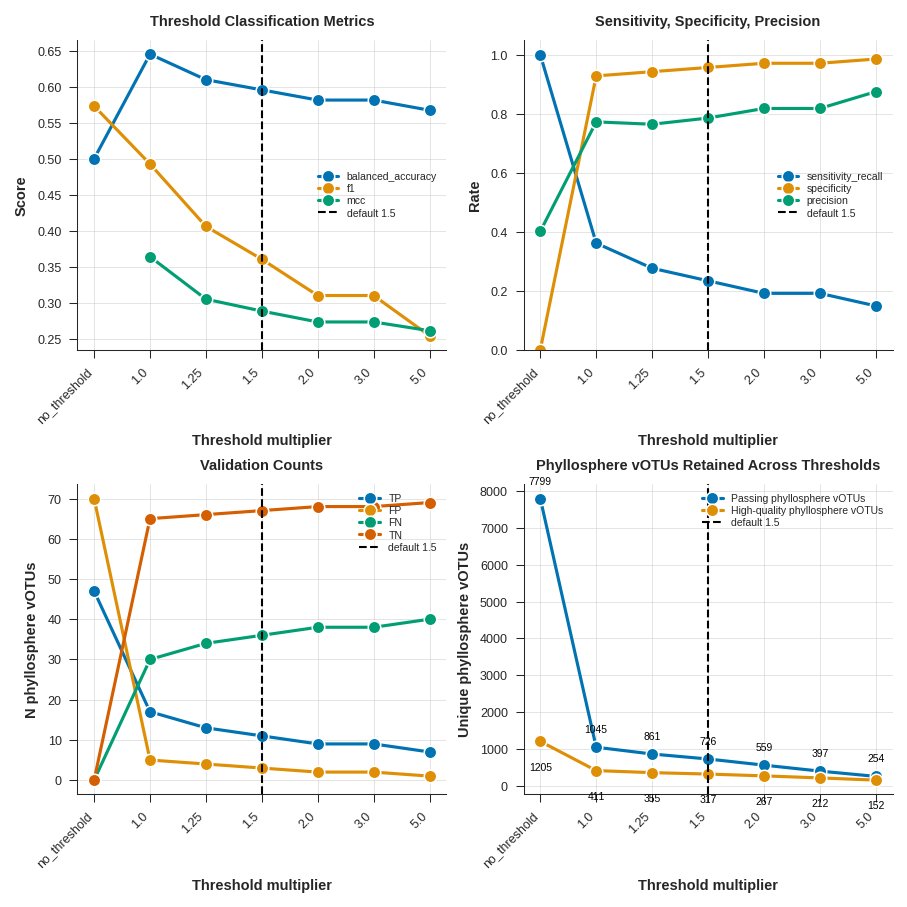

Threshold 1.5: 36 phyllosphere false negatives


,qseqid,ACTIVE,cohen_d_value,block_h_ratio,breadth
41,E_aphidicola_W06_8_pp1_cluster_9,True,-4.030771,83.425630,1.000062
16,vO3B_50_NODE_25_length_54009_cov_49.831671,True,-2.697804,135.819610,1.000018
109,vF3C_70_NODE_801_length_10365_cov_16.270029,True,-2.451822,81.924180,0.998263
85,vS3C_90_NODE_591_length_10141_cov_5.247373,True,-2.341141,6.376963,1.000095
24,vO3B_40_NODE_164_length_20880_cov_13.758415,True,-2.309279,137.229600,0.995038
29,vF2C_80_NODE_589_length_18775_cov_28.480929,True,-2.100259,162.851750,0.954803
104,vF2C_NODE_1058_length_11120_cov_8.168007,True,-2.086237,34.363132,0.868031
71,vO2C_NODE_895_length_16979_cov_80.447235,True,-2.072059,13.940969,1.000059
67,vO2B_70_NODE_316_length_22682_cov_8.612940,True,-1.898807,9.410780,0.998278
100,vS1B_80_NODE_6_length_162410_cov_176.552314_pr...,True,-1.884233,5.200998,1.000042


,threshold_multiplier,false_negatives,median_cohen_d_value,median_block_h_ratio,median_breadth
0,no_threshold,0,<NA>,<NA>,<NA>
1,1.0,30,-1.469082,8.136996,0.960904
2,1.25,34,-1.503703,8.935977,0.975525
3,1.5,36,-1.503703,10.65454,0.987302
4,2.0,38,-1.530942,12.291917,0.987302
5,3.0,38,-1.530942,12.291917,0.987302
6,5.0,40,-1.530942,12.291917,0.987302


In [15]:
# Summarize the detailed sample-by-threshold table into one row per threshold multiplier.
# Downstream reporting is phyllosphere-gated: non-phyllosphere vOTUs are not counted here.
threshold_overall_summary = (
    threshold_sample_summary
    .groupby("threshold_multiplier")
    .agg(
        samples=("sample", "nunique"),
        mean_passing_phyllosphere_vOTUs=("passing_phyllosphere_vOTUs", "mean"),
        median_passing_phyllosphere_vOTUs=("passing_phyllosphere_vOTUs", "median"),
        mean_passing_high_quality_phyllosphere_vOTUs=("passing_high_quality_phyllosphere_vOTUs", "mean"),
        median_passing_high_quality_phyllosphere_vOTUs=("passing_high_quality_phyllosphere_vOTUs", "median"),
    )
    .reset_index()
)

phyllosphere_vOTU_ids = set(list_phyllosphere_vOTUs)
high_quality_phyllosphere_vOTU_ids = set(list_phyllosphere_vOTUs_high)


# Add unique phyllosphere candidate counts per threshold across all samples.
# These counts are useful because the same vOTU can pass in multiple samples.
threshold_overall_summary["unique_passing_phyllosphere_vOTUs"] = threshold_overall_summary["threshold_multiplier"].map(
    lambda threshold: len(passing_phyllosphere_ids_for_threshold(threshold))
)
threshold_overall_summary["unique_passing_high_quality_phyllosphere_vOTUs"] = threshold_overall_summary["threshold_multiplier"].map(
    lambda threshold: len(passing_phyllosphere_ids_for_threshold(threshold).intersection(high_quality_phyllosphere_vOTU_ids))
)
threshold_overall_summary["unique_passing_true_positives"] = threshold_overall_summary["threshold_multiplier"].map(
    lambda threshold: len(passing_phyllosphere_ids_for_threshold(threshold).intersection(true_positive_contigs))
)
threshold_overall_summary["unique_passing_false_positives"] = threshold_overall_summary["threshold_multiplier"].map(
    lambda threshold: len(passing_phyllosphere_ids_for_threshold(threshold).intersection(false_positive_contigs))
)

# Keep no_threshold first, then numeric thresholds in ascending order.
threshold_summary_order = ["no_threshold"] + sorted(
    [threshold for threshold in threshold_overall_summary["threshold_multiplier"] if threshold != "no_threshold"],
    key=float,
)
threshold_summary_order_map = {threshold: i for i, threshold in enumerate(threshold_summary_order)}
threshold_overall_summary = (
    threshold_overall_summary
    .assign(threshold_order=threshold_overall_summary["threshold_multiplier"].map(threshold_summary_order_map))
    .sort_values("threshold_order")
    .drop(columns="threshold_order")
    .reset_index(drop=True)
)

# Display the aggregate sensitivity summary.
display(threshold_overall_summary)

# Print the phyllosphere false-positive contigs that pass at each threshold.
for threshold in threshold_overall_summary["threshold_multiplier"]:
    passing_false_positive_ids = sorted(
        passing_phyllosphere_ids_for_threshold(threshold).intersection(false_positive_contigs)
    )
    print(f"\nThreshold {threshold}: {len(passing_false_positive_ids)} passing phyllosphere false positives")
    for contig in passing_false_positive_ids:
        print(contig)

# Score thresholds against known true positives and known false positives.
# Known positives/negatives are also phyllosphere-gated so non-phyllosphere vOTUs do not affect the metric.
known_positive_ids = set(true_positive_contigs).intersection(phyllosphere_vOTU_ids)
known_negative_ids = set(false_positive_contigs).intersection(phyllosphere_vOTU_ids)
n_known_positives = len(known_positive_ids)
n_known_negatives = len(known_negative_ids)

threshold_metric_rows = []
for threshold in threshold_overall_summary["threshold_multiplier"]:
    passing_ids = passing_phyllosphere_ids_for_threshold(threshold)

    tp = len(passing_ids.intersection(known_positive_ids))
    fp = len(passing_ids.intersection(known_negative_ids))
    fn = n_known_positives - tp
    tn = n_known_negatives - fp

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else pd.NA
    specificity = tn / (tn + fp) if (tn + fp) > 0 else pd.NA
    precision = tp / (tp + fp) if (tp + fp) > 0 else pd.NA
    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else pd.NA
    false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else pd.NA
    balanced_accuracy = (sensitivity + specificity) / 2 if pd.notna(sensitivity) and pd.notna(specificity) else pd.NA
    youden_j = sensitivity + specificity - 1 if pd.notna(sensitivity) and pd.notna(specificity) else pd.NA
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else pd.NA
    mcc_denominator = ((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)) ** 0.5
    mcc = ((tp * tn) - (fp * fn)) / mcc_denominator if mcc_denominator > 0 else pd.NA

    threshold_metric_rows.append({
        "threshold_multiplier": threshold,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "sensitivity_recall": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "false_positive_rate": false_positive_rate,
        "false_negative_rate": false_negative_rate,
        "balanced_accuracy": balanced_accuracy,
        "youden_j": youden_j,
        "f1": f1,
        "mcc": mcc,
        "unique_passing_phyllosphere_vOTUs": len(passing_ids),
    })

threshold_validation_metrics = pd.DataFrame(threshold_metric_rows)
threshold_validation_metrics["threshold_sort"] = threshold_validation_metrics["threshold_multiplier"].map(
    lambda threshold: -1 if threshold == "no_threshold" else float(threshold)
)

threshold_validation_metrics_ranked = threshold_validation_metrics.sort_values(
    ["balanced_accuracy", "youden_j", "FP", "TP", "threshold_sort"],
    ascending=[False, False, True, False, True],
).drop(columns="threshold_sort")

display(threshold_validation_metrics_ranked)

best_threshold_row = threshold_validation_metrics_ranked.iloc[0]
print(
    "Best threshold by phyllosphere-gated balanced accuracy / Youden's J: "
    f"{best_threshold_row['threshold_multiplier']} "
    f"(TP={best_threshold_row['TP']}, FP={best_threshold_row['FP']}, "
    f"TN={best_threshold_row['TN']}, FN={best_threshold_row['FN']}, "
    f"balanced_accuracy={best_threshold_row['balanced_accuracy']:.3f}, "
    f"youden_j={best_threshold_row['youden_j']:.3f})"
)

# Plot threshold validation metrics to visualize the TP/FP tradeoff.
# Keep no_threshold as the first x-axis category.
threshold_plot_order = ["no_threshold"] + sorted(
    [threshold for threshold in threshold_validation_metrics["threshold_multiplier"] if threshold != "no_threshold"],
    key=float,
)
threshold_x_map = {threshold: i for i, threshold in enumerate(threshold_plot_order)}
threshold_x_labels = [str(threshold) for threshold in threshold_plot_order]
default_threshold_x = threshold_x_map.get(DEFAULT_THRESHOLD)

plot_metrics_df = threshold_validation_metrics.copy()
plot_metrics_df["threshold_x"] = plot_metrics_df["threshold_multiplier"].map(threshold_x_map)
plot_metrics_df = plot_metrics_df.sort_values("threshold_x")

fig, axes = plt.subplots(2, 2, figsize=(6, 6))

metric_long_df = plot_metrics_df.melt(
    id_vars=["threshold_multiplier", "threshold_x"],
    value_vars=["balanced_accuracy", "f1", "mcc"],
    var_name="metric",
    value_name="value",
)
sns.lineplot(
    data=metric_long_df,
    x="threshold_x",
    y="value",
    hue="metric",
    marker="o",
    ax=axes[0, 0],
)
axes[0, 0].set_title("Threshold Classification Metrics")
axes[0, 0].set_xlabel("Threshold multiplier")
axes[0, 0].set_ylabel("Score")
if default_threshold_x is not None:
    axes[0, 0].axvline(default_threshold_x, color="black", linestyle="--", linewidth=1, label=f"default {DEFAULT_THRESHOLD}")
axes[0, 0].legend(frameon=False)

rate_long_df = plot_metrics_df.melt(
    id_vars=["threshold_multiplier", "threshold_x"],
    value_vars=["sensitivity_recall", "specificity", "precision"],
    var_name="metric",
    value_name="value",
)
sns.lineplot(
    data=rate_long_df,
    x="threshold_x",
    y="value",
    hue="metric",
    marker="o",
    ax=axes[0, 1],
)
axes[0, 1].set_title("Sensitivity, Specificity, Precision")
axes[0, 1].set_xlabel("Threshold multiplier")
axes[0, 1].set_ylabel("Rate")
axes[0, 1].set_ylim(0, 1.05)
if default_threshold_x is not None:
    axes[0, 1].axvline(default_threshold_x, color="black", linestyle="--", linewidth=1, label=f"default {DEFAULT_THRESHOLD}")
axes[0, 1].legend(frameon=False)

count_long_df = plot_metrics_df.melt(
    id_vars=["threshold_multiplier", "threshold_x"],
    value_vars=["TP", "FP", "FN", "TN"],
    var_name="class",
    value_name="count",
)
sns.lineplot(
    data=count_long_df,
    x="threshold_x",
    y="count",
    hue="class",
    marker="o",
    ax=axes[1, 0],
)
axes[1, 0].set_title("Validation Counts")
axes[1, 0].set_xlabel("Threshold multiplier")
axes[1, 0].set_ylabel("N phyllosphere vOTUs")
if default_threshold_x is not None:
    axes[1, 0].axvline(default_threshold_x, color="black", linestyle="--", linewidth=1, label=f"default {DEFAULT_THRESHOLD}")
axes[1, 0].legend(frameon=False)

retention_plot_df = threshold_overall_summary.copy()
retention_plot_df["threshold_x"] = retention_plot_df["threshold_multiplier"].map(threshold_x_map)
retention_plot_df = retention_plot_df.sort_values("threshold_x")

retention_long_df = retention_plot_df.melt(
    id_vars=["threshold_multiplier", "threshold_x"],
    value_vars=[
        "unique_passing_phyllosphere_vOTUs",
        "unique_passing_high_quality_phyllosphere_vOTUs",
    ],
    var_name="sequence_set",
    value_name="count",
)
retention_label_map = {
    "unique_passing_phyllosphere_vOTUs": "Passing phyllosphere vOTUs",
    "unique_passing_high_quality_phyllosphere_vOTUs": "High-quality phyllosphere vOTUs",
}
retention_long_df["sequence_set"] = retention_long_df["sequence_set"].map(retention_label_map)

sns.lineplot(
    data=retention_long_df,
    x="threshold_x",
    y="count",
    hue="sequence_set",
    marker="o",
    ax=axes[1, 1],
)

# Annotate retained phyllosphere vOTU counts on the retention plot.
for _, row in retention_long_df.iterrows():
    y_offset = 6 if row["sequence_set"] == "Passing phyllosphere vOTUs" else -10

    axes[1, 1].annotate(
        f"{int(row['count'])}",
        xy=(row["threshold_x"], row["count"]),
        xytext=(0, y_offset),
        textcoords="offset points",
        ha="center",
        va="bottom" if y_offset > 0 else "top",
        fontsize=5,
        color="black",
    )
axes[1, 1].set_title("Phyllosphere vOTUs Retained Across Thresholds")
axes[1, 1].set_xlabel("Threshold multiplier")
axes[1, 1].set_ylabel("Unique phyllosphere vOTUs")
if default_threshold_x is not None:
    axes[1, 1].axvline(default_threshold_x, color="black", linestyle="--", linewidth=1, label=f"default {DEFAULT_THRESHOLD}")
axes[1, 1].legend(frameon=False)

for ax in axes.flat:
    ax.set_xticks(list(threshold_x_map.values()))
    ax.set_xticklabels(threshold_x_labels, rotation=45, ha="right")
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

# Inspect false negatives: known phyllosphere true positives that fail a selected threshold.
# These rows come from active_calls_df, where the true/false-positive labels were defined.
threshold_to_inspect = DEFAULT_THRESHOLD
passing_at_threshold = passing_phyllosphere_ids_for_threshold(threshold_to_inspect)
false_negative_ids = sorted(known_positive_ids - passing_at_threshold)

false_negative_cols = [
    "qseqid",
    "ACTIVE",
    "cohen_d_value",
    "block_h_ratio",
    "breadth",
]
false_negative_cols = [col for col in false_negative_cols if col in active_calls_df.columns]

false_negative_inspection_df = (
    active_calls_df.loc[active_calls_df["qseqid"].isin(false_negative_ids), false_negative_cols]
    .copy()
    .sort_values(["cohen_d_value", "block_h_ratio"], ascending=[True, True])
)

print(f"Threshold {threshold_to_inspect}: {len(false_negative_ids)} phyllosphere false negatives")
display(false_negative_inspection_df)

# Optional: summarize how many known phyllosphere true positives are false negatives at every threshold.
false_negative_summary_rows = []
for threshold in threshold_overall_summary["threshold_multiplier"]:
    passing_ids = passing_phyllosphere_ids_for_threshold(threshold)
    threshold_false_negative_ids = sorted(known_positive_ids - passing_ids)
    threshold_fn_df = active_calls_df[active_calls_df["qseqid"].isin(threshold_false_negative_ids)]

    false_negative_summary_rows.append({
        "threshold_multiplier": threshold,
        "false_negatives": len(threshold_false_negative_ids),
        "median_cohen_d_value": threshold_fn_df["cohen_d_value"].median() if len(threshold_fn_df) > 0 else pd.NA,
        "median_block_h_ratio": threshold_fn_df["block_h_ratio"].median() if len(threshold_fn_df) > 0 else pd.NA,
        "median_breadth": threshold_fn_df["breadth"].median() if "breadth" in threshold_fn_df.columns and len(threshold_fn_df) > 0 else pd.NA,
    })

false_negative_summary_df = pd.DataFrame(false_negative_summary_rows)
display(false_negative_summary_df)


### Detailed per-sample threshold summary


In [16]:
# Display the per-sample/per-threshold summary requested above.
# Each sample appears once for each threshold multiplier.
# Counts shown here are phyllosphere-gated.
threshold_sample_summary_display = threshold_sample_summary[[
    "sample",
    "threshold_multiplier",
    "microbial_background_trimmed_mean",
    "abundance_cutoff",
    "top_background_contig",
    "top_background_origin",
    "passing_phyllosphere_vOTUs",
    "passing_high_quality_phyllosphere_vOTUs",
    "passing_ubiquitous_phages",
    "passing_core_phages",
    "passing_true_positives",
    "passing_false_positives",
]].sort_values(["sample", "threshold_multiplier"])

# Use explicit display so the dataframe renders even if more code is added later.
threshold_sample_summary_display


,sample,threshold_multiplier,microbial_background_trimmed_mean,abundance_cutoff,top_background_contig,top_background_origin,passing_phyllosphere_vOTUs,passing_high_quality_phyllosphere_vOTUs,passing_ubiquitous_phages,passing_core_phages,passing_true_positives,passing_false_positives
64,vF1A,1.0,138.60838,138.608380,bF1A_NODE_523_length_11943_cov_40.450370,MG_ASSEMBLY,25,11,4,15,5,2
65,vF1A,1.25,138.60838,173.260475,bF1A_NODE_523_length_11943_cov_40.450370,MG_ASSEMBLY,24,11,4,14,5,1
66,vF1A,1.5,138.60838,207.912570,bF1A_NODE_523_length_11943_cov_40.450370,MG_ASSEMBLY,20,9,4,13,5,1
67,vF1A,2.0,138.60838,277.216760,bF1A_NODE_523_length_11943_cov_40.450370,MG_ASSEMBLY,17,8,4,12,5,0
68,vF1A,3.0,138.60838,415.825140,bF1A_NODE_523_length_11943_cov_40.450370,MG_ASSEMBLY,14,6,4,11,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...
59,vZ3,1.5,32.56765,48.851475,vZ3_NODE_25_length_13764_cov_21.814283,MICROBIAL,31,16,9,24,6,0
60,vZ3,2.0,32.56765,65.135300,vZ3_NODE_25_length_13764_cov_21.814283,MICROBIAL,30,16,9,23,5,0
61,vZ3,3.0,32.56765,97.702950,vZ3_NODE_25_length_13764_cov_21.814283,MICROBIAL,27,14,7,20,4,0
62,vZ3,5.0,32.56765,162.838250,vZ3_NODE_25_length_13764_cov_21.814283,MICROBIAL,21,9,6,16,4,0


### Default-threshold active vOTU candidates


In [17]:
# Convert the default-threshold candidate list to a set and keep only IDs found in the phyllosphere vOTU metadata.
# positive_list comes from positive_lists_by_threshold[DEFAULT_THRESHOLD] in the sensitivity loop above.
positive_list = list(set(positive_list).intersection(list_phyllosphere_vOTUs))

# Show the number of unique active phyllosphere vOTU candidates at the default threshold.
print("default_threshold", DEFAULT_THRESHOLD)
print("unique_active_phyllosphere_vOTUs", len(set(positive_list)))

# Check how many retained candidates are ubiquitous or core vOTUs.
print("ubiquitous_phages", len(ubiquitous_phages), len(set(positive_list).intersection(ubiquitous_phages)))
print("core_phages", len(core_phages), len(set(positive_list).intersection(core_phages)))

# Print the final candidate IDs.
print(positive_list)


default_threshold 1.5
unique_active_phyllosphere_vOTUs 726
ubiquitous_phages 11 10
core_phages 403 174
['vF3A_50_NODE_23_length_40709_cov_91.664166', 'vO2B_50_NODE_66_length_45169_cov_123.676154', 'vF3A_NODE_15_length_46991_cov_28.383650', 'vOL_80_NODE_170_length_26885_cov_80.907864', 'vO2B_90_NODE_640_length_15845_cov_205.513933', 'vN3_10_NODE_19_length_13396_cov_27.859531', 'vO2B_T_40_NODE_18_length_15634_cov_38.943578', 'vF2C_NODE_199_length_41768_cov_141.551627', 'vF2aA_NODE_104_length_30555_cov_60.386623', 'vO3B_NODE_273_length_23917_cov_95.913670', 'vF3A_70_NODE_53_length_25273_cov_27.151677', 'vO2C_T_50_NODE_40_length_20143_cov_44.404072', 'vF3C_20_NODE_53_length_46639_cov_131.269792', 'vF3C_40_NODE_494_length_14414_cov_92.716624', 'vO3A_70_NODE_154_length_13639_cov_186.811985', 'bN2_NODE_1_length_49147_cov_59.494235', 'vF3A_NODE_202_length_11317_cov_37.558959', 'vF3A_NODE_71_length_23988_cov_100.958426', 'vN3_NODE_20_length_24199_cov_99.827783', 'vFL_90_NODE_170_length_18330_co

## 9. Visualize rank-abundance and threshold cutoffs

Plot ranked abundance profiles across samples with the microbial/background line and selected threshold cutoff.


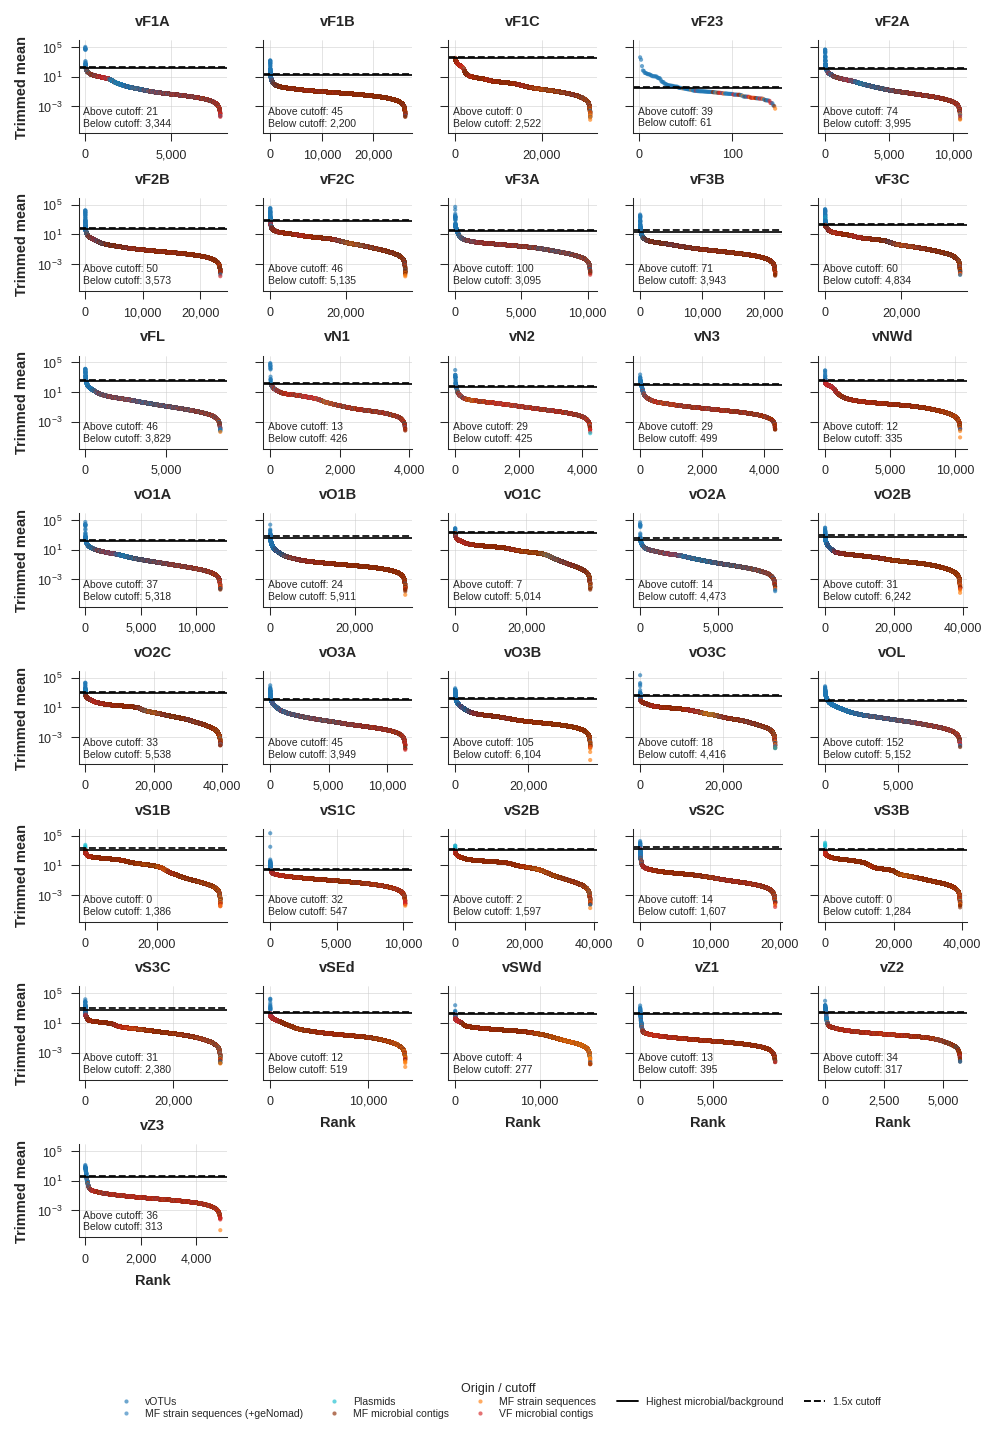

In [18]:
threshold_to_plot = DEFAULT_THRESHOLD
N_COLUMNS = 5
MAX_FIGURE_WIDTH_PT = 475
FACET_ASPECT = 1.1
facet_height = (MAX_FIGURE_WIDTH_PT * points_to_inches) / (N_COLUMNS * FACET_ASPECT)
TOP_N_RANKS = None  # set to None to plot all ranks per sample

min_length_to_plot = globals().get("MIN_BACKGROUND_LENGTH", 10000)
figure_outdir = Path(globals().get("OUTDIR", FIGURES_TABLES_DIR))

threshold_rank_df = rank_abundance_plot_df[
    rank_abundance_plot_df["ORIGIN"].eq("VIRAL")
    | (rank_abundance_plot_df["Length"] >= min_length_to_plot)
].copy()
threshold_rank_df = threshold_rank_df.sort_values(["sample", "Trimmed_Mean"], ascending=[True, False])
threshold_rank_df["rank"] = threshold_rank_df.groupby("sample").cumcount() + 1
threshold_rank_df["abundance_cutoff"] = np.where(
    threshold_to_plot == "no_threshold",
    0,
    threshold_rank_df["microbial_background_trimmed_mean"] * float(threshold_to_plot),
)
threshold_rank_df["passes_threshold"] = (
    threshold_rank_df["ORIGIN"].eq("VIRAL")
    & (threshold_rank_df["Trimmed_Mean"] > threshold_rank_df["abundance_cutoff"])
)
threshold_rank_df["excluded_by_genomad"] = threshold_rank_df["contig"].isin(predicted_phage_background_ids)
threshold_rank_df["plot_origin_raw"] = threshold_rank_df["ORIGIN"]
background_origin_mask = threshold_rank_df["ORIGIN"].isin(["MICROBIAL", "CULTURE", "MG_ASSEMBLY"])
threshold_rank_df.loc[
    background_origin_mask & threshold_rank_df["excluded_by_genomad"],
    "plot_origin_raw",
] = threshold_rank_df.loc[
    background_origin_mask & threshold_rank_df["excluded_by_genomad"],
    "ORIGIN",
] + " (+geNomad)"
threshold_rank_df["plot_origin"] = threshold_rank_df["plot_origin_raw"].map(origin_label_map).fillna(
    threshold_rank_df["plot_origin_raw"]
)

if TOP_N_RANKS is None:
    plot_df = threshold_rank_df.copy()
else:
    plot_df = (
        threshold_rank_df
        .groupby("sample", group_keys=False)
        .head(TOP_N_RANKS)
        .copy()
    )

g = sns.FacetGrid(
    plot_df,
    col="sample",
    col_wrap=N_COLUMNS,
    height=facet_height,
    aspect=FACET_ASPECT,
    sharex=False,
    sharey=True,
)

g.map_dataframe(
    sns.scatterplot,
    x="rank",
    y="Trimmed_Mean",
    hue="plot_origin",
    palette=plot_origin_palette,
    s=4,
    linewidth=0,
    alpha=0.65,
    rasterized=True,
)

for ax, sample in zip(g.axes.flat, g.col_names):
    sample_rows = threshold_rank_df[threshold_rank_df["sample"] == sample]

    microbial_background = sample_rows["microbial_background_trimmed_mean"].iloc[0]
    abundance_cutoff = sample_rows["abundance_cutoff"].iloc[0]

    ax.axhline(
        microbial_background,
        color="black",
        linestyle="-",
        linewidth=0.9,
        alpha=0.9,
    )
    ax.axhline(
        abundance_cutoff,
        color="black",
        linestyle="--",
        linewidth=0.9,
        alpha=0.9,
    )

    viral_rows = sample_rows[sample_rows["ORIGIN"].eq("VIRAL")]
    n_above_cutoff = viral_rows["passes_threshold"].sum()
    n_below_cutoff = len(viral_rows) - n_above_cutoff
    ax.text(
        0.03,
        0.06,
        f"Above cutoff: {n_above_cutoff:,}\nBelow cutoff: {n_below_cutoff:,}",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=5,
    )
    ax.xaxis.set_major_formatter("{x:,.0f}")

g.set(yscale="log")
g.set_axis_labels("Rank", "Trimmed mean")
g.set_titles("{col_name}")

# Remove per-axis legends.
for ax in g.axes.flat:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

# Origin legend.
origin_handles, origin_labels = g.axes.flat[0].get_legend_handles_labels()

# Add manual line legend.
line_handles = [
    Line2D(
        [0],
        [0],
        color="black",
        linestyle="-",
        linewidth=0.9,
        label="Highest microbial/background",
    ),
    Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        linewidth=0.9,
        label=f"{threshold_to_plot}x cutoff",
    ),
]

g.fig.legend(
    origin_handles + line_handles,
    origin_labels + [handle.get_label() for handle in line_handles],
    title="Origin / cutoff",
    bbox_to_anchor=(0.5, 0.01),
    loc="lower center",
    ncol=5,
    frameon=False,
)

plt.tight_layout(rect=[0, 0.10, 1, 1])
g.fig.savefig(
    figure_outdir / "SFigure2_rank_abundance_thresholds.pdf",
    bbox_inches="tight",
    dpi=300,
)
plt.show()


## 10. Export threshold-specific active vOTU FASTA files

Use each one-contig-per-line threshold list to create a threshold-specific FASTA, then dry-run the mapping workflow against each FASTA. Remove `-n` from the Snakemake command when you want to run the mapping jobs for real.


In [19]:
%%bash
set -euo pipefail

source /home/lmf/miniforge3/etc/profile.d/conda.sh
conda activate Mosaic_workflow

PROJECT_DIR="/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION"
MOSAIC_DIR="/home/lmf/apps/MOSAIC/mosaic"
SOURCE_FASTA="${PROJECT_DIR}/05_vOTUs/filtered_95-85_positive_viral_contigs.tot.fasta"
INPUT_DIR="${PROJECT_DIR}/00_RAW_DATA"
KRAKEN_DB="/home/lmf/db/KRAKEN/kraken/"
KRAKENUNIQ_DB="/home/lmf/db/KRAKEN/KrakenUniq"

cd "${MOSAIC_DIR}"

for list_file in "${PROJECT_DIR}"/active_vOTUs_list_threshold_*.txt; do
    threshold="${list_file##*/active_vOTUs_list_threshold_}"
    threshold="${threshold%.txt}"

    if [[ "${threshold}" == "no_threshold" ]]; then
        echo "Skipping no_threshold mapping"
        continue
    fi

    out_fasta="${PROJECT_DIR}/active_vOTUs_threshold_${threshold}.fasta"

    # echo "Extracting ${out_fasta} from ${list_file}"
    seqtk subseq "${SOURCE_FASTA}" "${list_file}" > "${out_fasta}"

    # echo "Dry-run mapping ${out_fasta}"
    echo "snakemake --use-conda -p map_to_reference --config input_dir="${INPUT_DIR}" kraken_db="${KRAKEN_DB}" krakenUniq_db="${KRAKENUNIQ_DB}" additional_reference_contigs="${out_fasta}" -j 144 -k -n"
done


snakemake --use-conda -p map_to_reference --config input_dir=/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/00_RAW_DATA kraken_db=/home/lmf/db/KRAKEN/kraken/ krakenUniq_db=/home/lmf/db/KRAKEN/KrakenUniq additional_reference_contigs=/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/active_vOTUs_threshold_1p0.fasta -j 144 -k -n
snakemake --use-conda -p map_to_reference --config input_dir=/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/00_RAW_DATA kraken_db=/home/lmf/db/KRAKEN/kraken/ krakenUniq_db=/home/lmf/db/KRAKEN/KrakenUniq additional_reference_contigs=/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/active_vOTUs_threshold_1p25.fasta -j 144 -k -n
snakemake --use-conda -p map_to_reference --config input_dir=/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/00_RAW_DATA kraken_db=/home/lmf/db/KRAKEN/kraken/ krakenUniq_db=/home/lmf/db/KRAKEN/KrakenUniq additional_reference_contigs=/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/active_vOTUs_threshold_1p5.fasta -j 144 -k -n
snakemake --use-conda -p

## 11. Map reads to filtered contigs at thresholds


In [20]:
# The previous bash cell generates dry-run mapping commands for all threshold FASTA files.
# Remove `-n` from a printed Snakemake command when you want to run that mapping job for real.


## 12. Lifestyle sensitivity across thresholds

Build threshold-specific metadata/RPKM tables, run temperate-vs-virulent statistics, and plot relative abundance, prevalence, and detected-vOTU proportions.


In [21]:
POSITIVE_LIST_THRESHOLDS = sorted([threshold for threshold in positive_lists_by_threshold if threshold != "no_threshold"])
THRESHOLDS_TO_PLOT = ["no_threshold"] + POSITIVE_LIST_THRESHOLDS


rpkm_by_threshold = {}


rpkm_norm_df = read_rpkm_for_threshold("no_threshold")

# The no-threshold set uses the full MOSAIC-compatible phyllosphere catalogue.
# Numeric thresholds use the original detected-only phyllosphere catalogue.
# Threshold-specific abundance/prevalence values are read from their own mapping outputs.
no_threshold_ids = set(list_phyllosphere_vOTUs_full)
threshold_catalog_ids = set(list_phyllosphere_vOTUs)


threshold_vOTU_counts = {
    threshold: len(get_threshold_metadata(threshold))
    for threshold in THRESHOLDS_TO_PLOT
}
threshold_label_map = {
    threshold: f"{threshold}\n(n={threshold_vOTU_counts[threshold]})"
    for threshold in THRESHOLDS_TO_PLOT
}

for threshold in THRESHOLDS_TO_PLOT:
    label = threshold_label(threshold)
    threshold_vOTUs = get_threshold_metadata(threshold)["vOTU"].dropna().astype(str).sort_values().to_list()

    pd.DataFrame({"vOTU": threshold_vOTUs}).to_csv(
        f"{OUTDIR}/active_vOTUs_threshold_{label}.csv",
        index=False,
    )

    with open(VIRAL_FRACTION_DIR / f"active_vOTUs_list_threshold_{label}.txt", "w") as f:
        f.write("\n".join(threshold_vOTUs) + ("\n" if threshold_vOTUs else ""))


# -----------------------------
# Run across thresholds
# -----------------------------
abundance_dfs = []
abundance_summaries = []
prevalence_dfs = []
prevalence_summaries = []

for threshold in THRESHOLDS_TO_PLOT:
    abundance_df, abundance_summary = lifestyle_relative_abundance_for_threshold(threshold)
    prevalence_df, prevalence_summary = lifestyle_prevalence_for_threshold(threshold)

    abundance_dfs.append(abundance_df)
    abundance_summaries.append(abundance_summary)
    prevalence_dfs.append(prevalence_df)
    prevalence_summaries.append(prevalence_summary)

abundance_threshold_df = pd.concat(abundance_dfs, ignore_index=True)
prevalence_threshold_df = pd.concat(prevalence_dfs, ignore_index=True)

lifestyle_threshold_summary = pd.concat(
    abundance_summaries + prevalence_summaries,
    ignore_index=True
)

lifestyle_threshold_summary.to_csv(
    f"{OUTDIR}/Lifestyle_threshold_sensitivity_stats.csv",
    index=False
)

display(lifestyle_threshold_summary)




/home/lmf/miniforge3/envs/bio/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5569.
  res = hypotest_fun_out(*samples, **kwds)
/tmp/ipykernel_2715136/2803706987.py:242: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  summary = pd.concat([group_summary, pd.DataFrame(results)], ignore_index=True)
/tmp/ipykernel_2715136/2803706987.py:242: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  s

,threshold,metric,Group,N,Mean,Median,Std,Test,Statistic,p_value,n_vOTUs,Shapiro_p,Normal?
0,no_threshold,relative_abundance,Temperate,36,56.031797,57.210365,21.874293,<NA>,<NA>,<NA>,7958,NaN,NaN
1,no_threshold,relative_abundance,Virulent,36,43.968203,42.789635,21.874293,<NA>,<NA>,<NA>,7958,NaN,NaN
2,no_threshold,relative_abundance,Paired difference,36,12.063593,14.420729,43.748585,Wilcoxon signed-rank,227.0,0.097796,7958,NaN,NaN
3,1.0,relative_abundance,Temperate,36,58.220692,59.886963,22.284015,<NA>,<NA>,<NA>,1045,NaN,NaN
4,1.0,relative_abundance,Virulent,36,41.779308,40.113037,22.284015,<NA>,<NA>,<NA>,1045,NaN,NaN
5,1.0,relative_abundance,Paired difference,36,16.441384,19.773927,44.568030,Wilcoxon signed-rank,189.0,0.022878,1045,NaN,NaN
6,1.25,relative_abundance,Temperate,36,58.533409,59.450651,22.879426,<NA>,<NA>,<NA>,861,NaN,NaN
7,1.25,relative_abundance,Virulent,36,41.466591,40.549349,22.879426,<NA>,<NA>,<NA>,861,NaN,NaN
8,1.25,relative_abundance,Paired difference,36,17.066817,18.901302,45.758852,Wilcoxon signed-rank,193.0,0.02716,861,NaN,NaN
9,1.5,relative_abundance,Temperate,36,58.577150,59.474494,23.001146,<NA>,<NA>,<NA>,726,NaN,NaN


### Lifestyle composition across thresholds

Compute and plot the proportion of detected active vOTUs assigned to each lifestyle at each threshold.


In [22]:
# Run detected-vOTU lifestyle proportions across thresholds.
proportion_dfs = []
proportion_summaries = []

for threshold in THRESHOLDS_TO_PLOT:
    prop_df, prop_summary = lifestyle_proportion_for_threshold(threshold)
    proportion_dfs.append(prop_df)
    proportion_summaries.append(prop_summary)

proportion_threshold_df = pd.concat(proportion_dfs, ignore_index=True)
proportion_threshold_summary = pd.concat(proportion_summaries, ignore_index=True)

proportion_threshold_summary.to_csv(
    f"{OUTDIR}/Lifestyle_Comparison_proportion_threshold_sensitivity_stats.csv",
    index=False
)

display(proportion_threshold_summary)


,threshold,metric,Group,N,Mean,Median,Std,Test,Statistic,p_value,n_vOTUs
0,no_threshold,detected_vOTU_proportion,Temperate,36,47.754602,46.630765,7.397866,<NA>,<NA>,<NA>,7958
1,no_threshold,detected_vOTU_proportion,Virulent,36,52.245398,53.369235,7.397866,<NA>,<NA>,<NA>,7958
2,no_threshold,detected_vOTU_proportion,Paired difference,36,-4.490797,-6.738469,14.795731,Wilcoxon signed-rank,213.0,0.059879,7958
3,1.0,detected_vOTU_proportion,Temperate,36,54.493779,52.219962,8.344012,<NA>,<NA>,<NA>,1045
4,1.0,detected_vOTU_proportion,Virulent,36,45.506221,47.780038,8.344012,<NA>,<NA>,<NA>,1045
5,1.0,detected_vOTU_proportion,Paired difference,36,8.987559,4.439923,16.688024,Wilcoxon signed-rank,172.0,0.010458,1045
6,1.25,detected_vOTU_proportion,Temperate,36,55.435148,53.056166,8.820889,<NA>,<NA>,<NA>,861
7,1.25,detected_vOTU_proportion,Virulent,36,44.564852,46.943834,8.820889,<NA>,<NA>,<NA>,861
8,1.25,detected_vOTU_proportion,Paired difference,36,10.870295,6.112332,17.641778,Wilcoxon signed-rank,138.0,0.003742,861
9,1.5,detected_vOTU_proportion,Temperate,36,54.418680,52.752454,7.996680,<NA>,<NA>,<NA>,726


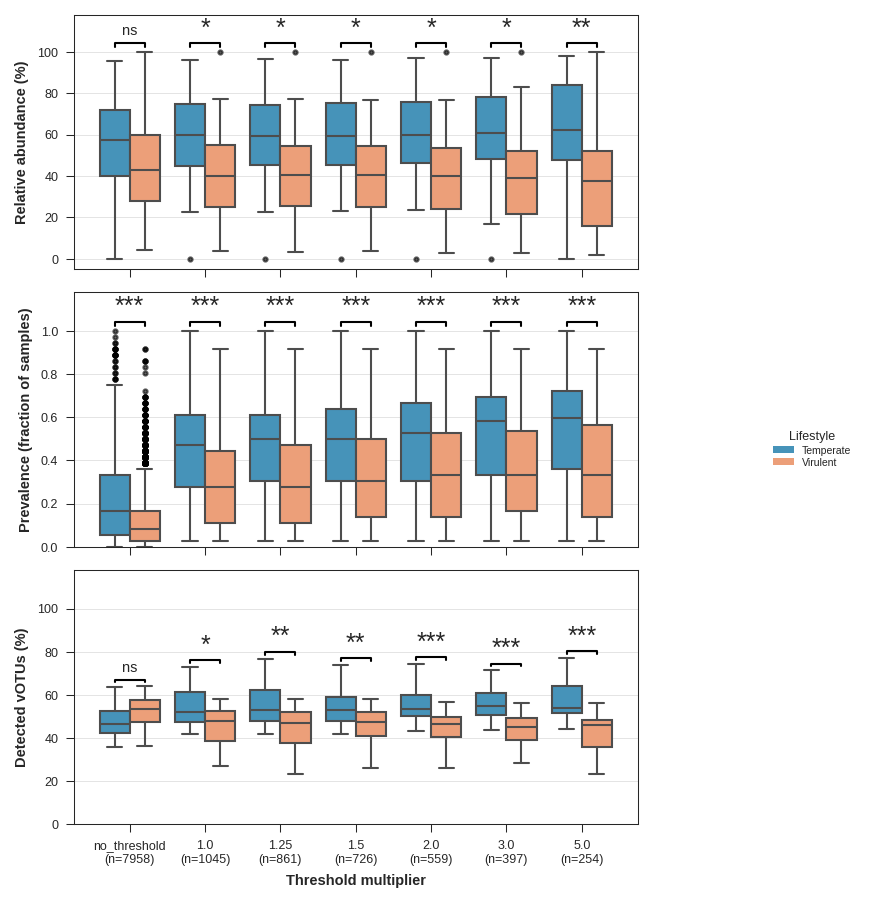

In [26]:
boxplot_flierprops = {
    "marker": "o",
    "markersize": 2,
    "markerfacecolor": "black",
    "markeredgecolor": "black",
    "alpha": 0.6,
}

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(5, 6),
    sharex=True,
)

plot_specs = [
    {
        "ax": axes[0],
        "data": abundance_threshold_df,
        "y": "RelativeAbundance",
        "ylabel": "Relative abundance (%)",
        "ylim": (-5, 118),
        "bar_func": add_threshold_paired_bars,
        "bar_kwargs": {
            "summary_df": lifestyle_threshold_summary,
            "metric": "relative_abundance",
            "y_col": "RelativeAbundance",
            "data_df": abundance_threshold_df,
            "thresholds": THRESHOLDS_TO_PLOT,
        },
    },
    {
        "ax": axes[1],
        "data": prevalence_threshold_df,
        "y": "prevalence",
        "ylabel": "Prevalence (fraction of samples)",
        "ylim": (0, 1.18),
        "bar_func": add_threshold_test_bars,
        "bar_kwargs": {
            "summary_df": lifestyle_threshold_summary,
            "metric": "prevalence",
            "test": "Mann-Whitney U",
            "y_col": "prevalence",
            "data_df": prevalence_threshold_df,
            "thresholds": THRESHOLDS_TO_PLOT,
        },
    },
    {
        "ax": axes[2],
        "data": proportion_threshold_df,
        "y": "Proportion",
        "ylabel": "Detected vOTUs (%)",
        "ylim": (0, 118),
        "bar_func": add_threshold_paired_bars,
        "bar_kwargs": {
            "summary_df": proportion_threshold_summary,
            "metric": "detected_vOTU_proportion",
            "y_col": "Proportion",
            "data_df": proportion_threshold_df,
            "thresholds": THRESHOLDS_TO_PLOT,
        },
    },
]

legend_handles = None
legend_labels = None

for spec in plot_specs:
    ax = spec["ax"]

    sns.boxplot(
        data=spec["data"],
        x="threshold",
        y=spec["y"],
        hue="Lifestyle",
        order=THRESHOLDS_TO_PLOT,
        hue_order=["Temperate", "Virulent"],
        palette=lifestyle_palette,
        flierprops=boxplot_flierprops,
        ax=ax,
    )

    spec["bar_func"](
        ax=ax,
        **spec["bar_kwargs"],
    )

    ax.set_ylabel(spec["ylabel"])
    ax.set_xlabel("")
    ax.set_ylim(*spec["ylim"])

    handles, labels = ax.get_legend_handles_labels()
    if legend_handles is None:
        legend_handles = handles[:2]
        legend_labels = labels[:2]

    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

axes[-1].set_xlabel("Threshold multiplier")
axes[-1].set_xticks(
    range(len(THRESHOLDS_TO_PLOT)),
    [threshold_label_map[threshold] for threshold in THRESHOLDS_TO_PLOT],
)

fig.legend(
    legend_handles,
    legend_labels,
    title="Lifestyle",
    frameon=False,
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
    borderaxespad=0,
)

plt.tight_layout(rect=[0, 0, 0.86, 1])

plt.savefig(
    f"{OUTDIR}/SFigure5_Lifestyle_Comparison_threshold_sensitivity_combined.svg",
    bbox_inches="tight",
)

plt.show()


,threshold,threshold_label,category,count,color
0,1.00,1.0\n(n=1045),Low overlap/\nUnique,305,#666666
1,1.00,1.0\n(n=1045),Common,375,#CCCCCC
2,1.00,1.0\n(n=1045),Core,347,#33CC99
3,1.00,1.0\n(n=1045),Ubiquitous,14,#FFCC00
4,1.25,1.25\n(n=861),Low overlap/\nUnique,237,#666666
5,1.25,1.25\n(n=861),Common,303,#CCCCCC
6,1.25,1.25\n(n=861),Core,305,#33CC99
7,1.25,1.25\n(n=861),Ubiquitous,14,#FFCC00
8,1.50,1.5\n(n=726),Low overlap/\nUnique,188,#666666
9,1.50,1.5\n(n=726),Common,246,#CCCCCC


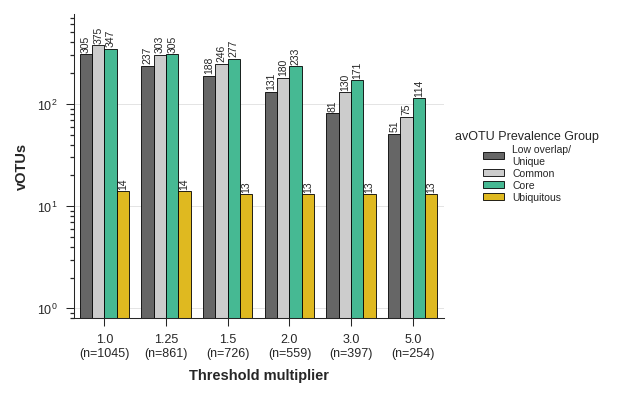

In [24]:
cutoff_20 = int(np.floor(len(SAMPLES_dk) * 0.20) + 1)
cutoff_50 = int(np.floor(len(SAMPLES_dk) * 0.50) + 1)
cutoff_100 = len(SAMPLES_dk)

linebreak = chr(10)
low_overlap_label = "Low overlap/" + linebreak + "Unique"
common_label = "Common"
core_label = "Core"
ubiquitous_label = "Ubiquitous"
core_count_category_order = [low_overlap_label, common_label, core_label, ubiquitous_label]
core_count_palette = {
    low_overlap_label: "#666666",
    common_label: "#CCCCCC",
    core_label: "#33CC99",
    ubiquitous_label: "#FFCC00",
}

prevalence_thresholds_to_plot = [threshold for threshold in THRESHOLDS_TO_PLOT if threshold != "no_threshold"]

threshold_core_count_rows = []
core_count_frames = []

for threshold in prevalence_thresholds_to_plot:
    threshold_rpkm_df = read_rpkm_for_threshold(threshold) if "read_rpkm_for_threshold" in globals() else rpkm_norm_df

    missing_dk_samples = sorted(set(SAMPLES_dk) - set(threshold_rpkm_df.columns))
    if missing_dk_samples:
        raise ValueError(f"Missing DK sample columns for threshold {threshold}: {missing_dk_samples}")

    if threshold == "no_threshold":
        threshold_votu_ids = set(globals().get("no_threshold_ids", list_phyllosphere_vOTUs_full))
    else:
        threshold_votu_ids = set(positive_lists_by_threshold[threshold]).intersection(
            set(globals().get("threshold_catalog_ids", list_phyllosphere_vOTUs))
        )

    threshold_counts_df = threshold_rpkm_df.loc[
        threshold_rpkm_df["vOTU"].isin(threshold_votu_ids),
        ["vOTU"] + SAMPLES_dk,
    ].copy()
    threshold_counts_df["threshold"] = threshold
    threshold_counts_df["sample_count"] = (threshold_counts_df[SAMPLES_dk] > 0).sum(axis=1)

    threshold_counts_df["type"] = "#CCCCCC"
    threshold_counts_df.loc[threshold_counts_df["sample_count"] < cutoff_20, "type"] = "#666666"
    threshold_counts_df.loc[threshold_counts_df["sample_count"] >= cutoff_50, "type"] = "#33CC99"
    threshold_counts_df.loc[threshold_counts_df["sample_count"] == cutoff_100, "type"] = "#FFCC00"

    core_count_frames.append(threshold_counts_df[["threshold", "vOTU", "sample_count", "type"]])

    threshold_label_for_plot = threshold_label_map.get(threshold, str(threshold))
    threshold_core_count_rows.extend([
        {
            "threshold": threshold,
            "threshold_label": threshold_label_for_plot,
            "category": low_overlap_label,
            "count": int(((threshold_counts_df["sample_count"] > 0) & (threshold_counts_df["sample_count"] < cutoff_20)).sum()),
            "color": "#666666",
        },
        {
            "threshold": threshold,
            "threshold_label": threshold_label_for_plot,
            "category": common_label,
            "count": int(((threshold_counts_df["sample_count"] >= cutoff_20) & (threshold_counts_df["sample_count"] < cutoff_50)).sum()),
            "color": "#CCCCCC",
        },
        {
            "threshold": threshold,
            "threshold_label": threshold_label_for_plot,
            "category": core_label,
            "count": int(((threshold_counts_df["sample_count"] >= cutoff_50) & (threshold_counts_df["sample_count"] < cutoff_100)).sum()),
            "color": "#33CC99",
        },
        {
            "threshold": threshold,
            "threshold_label": threshold_label_for_plot,
            "category": ubiquitous_label,
            "count": int((threshold_counts_df["sample_count"] == cutoff_100).sum()),
            "color": "#FFCC00",
        },
    ])

df_abundances_core_counts = pd.concat(core_count_frames, ignore_index=True)
dk_core_count_summary = pd.DataFrame(threshold_core_count_rows)

dk_core_count_summary.to_csv(
    f"{OUTDIR}/DK_vOTU_prevalence_core_counts_by_threshold.csv",
    index=False,
)

display(dk_core_count_summary)

fig, ax = plt.subplots(figsize=(5, 2.6))

sns.barplot(
    data=dk_core_count_summary,
    x="threshold_label",
    y="count",
    hue="category",
    hue_order=core_count_category_order,
    palette=core_count_palette,
    edgecolor="black",
    linewidth=0.4,
    ax=ax,
)

for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", fontsize=5, padding=1, rotation=90)

ax.set_ylabel("vOTUs")
ax.set_xlabel("Threshold multiplier")
ax.set_yscale("log")
ax.set_ylim(0.8, dk_core_count_summary["count"].max() * 2)
ax.legend(
    title="avOTU Prevalence Group",
    frameon=False,
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
    borderaxespad=0,
)
sns.despine(ax=ax)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.savefig(
    f"{OUTDIR}/DK_vOTU_prevalence_core_counts_by_threshold.svg",
    bbox_inches="tight",
)
plt.show()


/tmp/ipykernel_2715136/2385741180.py:168: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.84, 1])


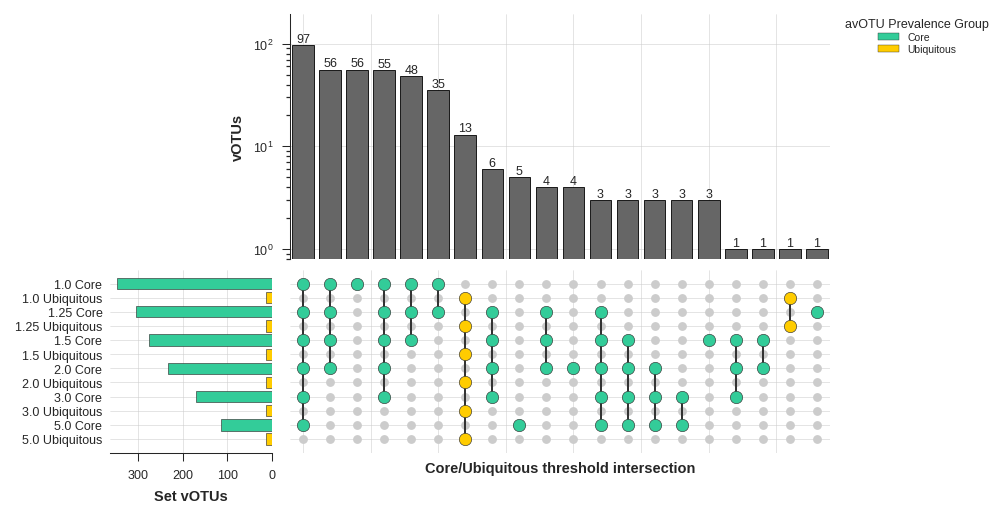

In [25]:
# UpSet-style overlap of Core and Ubiquitous vOTUs across numeric thresholds.
upset_thresholds_to_plot = [threshold for threshold in THRESHOLDS_TO_PLOT if threshold != "no_threshold"]
upset_prevalence_groups = [
    ("Core", "#33CC99", lambda sample_count: (sample_count >= cutoff_50) & (sample_count < cutoff_100)),
    ("Ubiquitous", "#FFCC00", lambda sample_count: sample_count == cutoff_100),
]

threshold_membership_sets = {}
threshold_membership_colors = {}

for threshold in upset_thresholds_to_plot:
    threshold_rows = df_abundances_core_counts[
        df_abundances_core_counts["threshold"] == threshold
    ].copy()

    for prevalence_group, prevalence_color, prevalence_mask in upset_prevalence_groups:
        membership_label = f"{threshold} {prevalence_group}"
        membership_rows = threshold_rows[prevalence_mask(threshold_rows["sample_count"])]
        threshold_membership_sets[membership_label] = set(membership_rows["vOTU"])
        threshold_membership_colors[membership_label] = prevalence_color

all_upset_votus = sorted(set().union(*threshold_membership_sets.values())) if threshold_membership_sets else []
upset_membership_df = pd.DataFrame({"vOTU": all_upset_votus})

for membership_label, membership_votus in threshold_membership_sets.items():
    upset_membership_df[membership_label] = upset_membership_df["vOTU"].isin(membership_votus)

threshold_columns = list(threshold_membership_sets.keys())

if upset_membership_df.empty:
    upset_intersections = pd.DataFrame(columns=threshold_columns + ["count", "degree"])
else:
    upset_intersections = (
        upset_membership_df
        .groupby(threshold_columns, dropna=False)
        .size()
        .reset_index(name="count")
    )
    upset_intersections = upset_intersections[upset_intersections["count"] > 0].copy()
    upset_intersections["degree"] = upset_intersections[threshold_columns].sum(axis=1)
    upset_intersections = upset_intersections.sort_values(
        ["count", "degree"],
        ascending=[False, False],
    ).reset_index(drop=True)

MAX_UPSET_INTERSECTIONS = 30
upset_plot_df = upset_intersections.head(MAX_UPSET_INTERSECTIONS).copy()

upset_intersections.to_csv(
    f"{OUTDIR}/DK_vOTU_threshold_core_ubiquitous_upset_intersections.csv",
    index=False,
)

fig = plt.figure(figsize=(6.2, 3.8))
grid = fig.add_gridspec(
    nrows=2,
    ncols=2,
    width_ratios=[1.2, 4.0],
    height_ratios=[2.0, 1.5],
    wspace=0.05,
    hspace=0.05,
)
ax_empty = fig.add_subplot(grid[0, 0])
ax_matrix = fig.add_subplot(grid[1, 1])
ax_bar = fig.add_subplot(grid[0, 1], sharex=ax_matrix)
ax_set_size = fig.add_subplot(grid[1, 0], sharey=ax_matrix)
ax_empty.axis("off")

x_positions = np.arange(len(upset_plot_df))
y_positions = np.arange(len(threshold_columns))
set_sizes = [len(threshold_membership_sets[label]) for label in threshold_columns]
set_colors = [threshold_membership_colors[label] for label in threshold_columns]

ax_bar.bar(
    x_positions,
    upset_plot_df["count"],
    color="#666666",
    edgecolor="black",
    linewidth=0.4,
)
ax_bar.set_ylabel("vOTUs")
ax_bar.tick_params(axis="x", bottom=False, labelbottom=False)
ax_bar.set_yscale("log")
if len(upset_plot_df) > 0:
    ax_bar.set_ylim(0.8, upset_plot_df["count"].max() * 2)

for x, count in zip(x_positions, upset_plot_df["count"]):
    ax_bar.text(
        x,
        count,
        f"{count:,.0f}",
        ha="center",
        va="bottom",
        fontsize=6,
        # rotation=90,
    )

ax_set_size.barh(
    y_positions,
    set_sizes,
    color=set_colors,
    edgecolor="#333333",
    linewidth=0.3,
)
ax_set_size.set_xlabel("Set vOTUs")
ax_set_size.set_yticks(y_positions)
ax_set_size.set_yticklabels(threshold_columns)
ax_set_size.invert_xaxis()
ax_set_size.tick_params(axis="y", length=0)

for y, membership_label in enumerate(threshold_columns):
    membership = upset_plot_df[membership_label].to_numpy(dtype=bool) if len(upset_plot_df) > 0 else np.array([], dtype=bool)
    active_x = x_positions[membership]

    ax_matrix.scatter(
        x_positions,
        np.full_like(x_positions, y),
        s=18,
        color="#CCCCCC",
        zorder=1,
    )
    ax_matrix.scatter(
        active_x,
        np.full_like(active_x, y),
        s=35,
        color=threshold_membership_colors[membership_label],
        edgecolor="#333333",
        linewidth=0.3,
        zorder=2,
    )

    for x in active_x:
        active_rows = np.where(upset_plot_df.loc[x, threshold_columns].to_numpy(dtype=bool))[0]
        if len(active_rows) > 1:
            ax_matrix.plot(
                [x, x],
                [active_rows.min(), active_rows.max()],
                color="#333333",
                linewidth=0.9,
                zorder=1.5,
            )

ax_matrix.set_yticks(y_positions)
ax_matrix.tick_params(axis="y", labelleft=False)
ax_matrix.invert_yaxis()
ax_matrix.set_xlabel("Core/Ubiquitous threshold intersection")
ax_matrix.set_xlim(-0.5, max(len(upset_plot_df) - 0.5, 0.5))
ax_matrix.tick_params(axis="x", bottom=False, labelbottom=False)
ax_matrix.tick_params(axis="y", length=0)

legend_handles = [
    Patch(facecolor="#33CC99", edgecolor="#333333", linewidth=0.2, label="Core"),
    Patch(facecolor="#FFCC00", edgecolor="#333333", linewidth=0.2, label="Ubiquitous"),
]
ax_bar.legend(
    handles=legend_handles,
    title="avOTU Prevalence Group",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
)

sns.despine(ax=ax_bar, bottom=True)
sns.despine(ax=ax_matrix, left=True, bottom=True)
sns.despine(ax=ax_set_size, left=True)

plt.tight_layout(rect=[0, 0, 0.84, 1])
plt.savefig(
    f"{OUTDIR}/DK_vOTU_threshold_core_ubiquitous_upset.svg",
    bbox_inches="tight",
)
plt.show()
